# **ETL y Análisis Exploratorio — Seguro Agrícola Indexado de Café**

**Salida:** `data/processed/features_modelo.csv` y `data/processed/panel_municipal.csv`

Este notebook carga, limpia y consolida todas las fuentes de datos, calcula el SPI-3
y construye el panel integrado. Los resultados se persisten en `data/processed/`
para ser consumidos posteriormente.

## **0. Configuración del entorno**

Esta sección instala las librerias necesarias, define las constantes globales del proyecto
y establece los parametros de diseño del seguro (umbrales SPI-3) que se usarán en todo el notebook.


In [1]:
!pip install -q yfinance

In [2]:
# Importar librerías
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gamma as gamma_dist
from scipy.stats import norm as norm_dist
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, f1_score,
                              r2_score, mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import StandardScaler

try:
    import yfinance as yf
    YFINANCE_OK = True
except ImportError:
    YFINANCE_OK = False

print('Librerias cargadas correctamente.')
print(f'  numpy  {np.__version__}')
print(f'  pandas {pd.__version__}')
print(f'  yfinance disponible: {YFINANCE_OK}')

Librerias cargadas correctamente.
  numpy  1.26.4
  pandas 2.2.2
  yfinance disponible: True


In [3]:
# Constantes globales
BASE  = 'https://raw.githubusercontent.com/valevipa/Proyecto_Seguro_Cafe_Indexado/refs/heads/main/data/raw/'
SEED  = 42

COLORES = {
    'Quindio' : '#2196F3',
    'Quindio_tilde' : '#2196F3',
    'Narino'  : '#4CAF50',
    'sequia'  : '#FF5722',
    'exceso'  : '#9C27B0',
    'normal'  : '#9E9E9E',
    'elnino'  : '#FFD600',
}

# Umbrales SPI-3 de diseno inicial
UMBRALES = {
    'Narino'  : {'sequia': -1.255, 'exceso':  1.117},
    'Nariño': {'sequia': -1.255, 'exceso':  1.117},
    'Quindio' : {'sequia': -1.137, 'exceso':  1.221},
    'Quindío': {'sequia': -1.137, 'exceso':  1.221},
}

# Meses para parsear Excel IDEAM
MESES = {
    'Ene': 1,  'Ene.': 1,
    'Feb': 2,  'Feb.': 2,
    'Mar': 3,  'Mar.': 3,
    'Abr': 4,  'Abr.': 4,
    'May': 5,  'May.': 5,
    'Jun': 6,  'Jun.': 6,
    'Jul': 7,  'Jul.': 7,
    'Ago': 8,  'Ago.': 8,
    'Sep': 9,  'Sep.': 9,
    'Oct': 10, 'Oct.': 10,
    'Nov': 11, 'Nov.': 11,
    'Dic': 12, 'Dic.': 12,
}

np.random.seed(SEED)
print('Constantes definidas:')
print(f'  BASE     = {BASE}')
print(f'  SEED     = {SEED}')
print(f'  UMBRALES = {UMBRALES}')
OUT = '/content/outputs'
os.makedirs(OUT, exist_ok=True)

Constantes definidas:
  BASE     = https://raw.githubusercontent.com/valevipa/Proyecto_Seguro_Cafe_Indexado/refs/heads/main/data/raw/
  SEED     = 42
  UMBRALES = {'Narino': {'sequia': -1.255, 'exceso': 1.117}, 'Nariño': {'sequia': -1.255, 'exceso': 1.117}, 'Quindio': {'sequia': -1.137, 'exceso': 1.221}, 'Quindío': {'sequia': -1.137, 'exceso': 1.221}}


## **1. Carga de datos (ETL)**

En esta sección cargamos y limpiamos todas las fuentes de datos del proyecto.
Cada sub-seccion corresponde a una fuente distinta. Al final de cada sub-seccion
se imprime un resumen del DataFrame resultante.

**Fuentes:**
1. ERA5 -- Análisis climático de precipitación (ECMWF, 0.25 grados)
2. EVA -- Evaluaciones Agropecuarias Municipales (MADR Colombia)
3. IDEAM -- Temperatura y humedad relativa (estaciones meteorológicas)
4. MODIS -- NDVI/EVI satelital (NASA Terra/Aqua, resolución 500m)
5. Precios café -- NYMEX KC=F en dólares, convertidos a pesos colombianos


### **1.1 ERA5 -- Precipitación mensual (2000-2024)**

ERA5 es el análisis climatico de ECMWF. Para este proyecto se descargaron datos
de precipitación mensual en una malla de puntos que cubre Quindio y Nariño.

**Agregacion ponderada por area cafetera (Nariño):**  
Nariño tiene 16 puntos de grilla ERA5 (~31 km), pero el cafe se concentra en el
noreste del departamento (La Unión, San Lorenzo, Buesaco, etc.). Los 14 puntos
restantes cubren la costa Pacifica y zonas sin café. Se ponderan los 2 puntos
cafeteros por su área cosechada EVA (promedio 2007-2024) y se excluyen los demas.
Quindio tiene un solo punto de grilla por lo que no requiere ponderacion.


In [4]:
# 1.1 ERA5 precipitacion mensual (2000-2024 consolidado)
era5_hist = pd.read_csv(BASE + 'era5_precip_quindio_narino_consolidado.csv')
era5_new  = pd.read_csv(BASE + 'era5_precip_quindio_narino_2018_2024.csv')
era5_raw  = (pd.concat([era5_hist, era5_new], ignore_index=True)
               .drop_duplicates(subset=['time', 'lat', 'lon']))

print('ERA5 consolidado 2000-2024:')
print('  Shape    :', era5_raw.shape)
print('  Columnas :', era5_raw.columns.tolist())
print('  Rango    :', era5_raw['time'].min(), '->', era5_raw['time'].max())
print(era5_raw.tail(3))


ERA5 consolidado 2000-2024:
  Shape    : (5100, 9)
  Columnas : ['time', 'lat', 'lon', 'precip_mm_day', 'year', 'month', 'days_in_month', 'precip_mm_month', 'departamento']
  Rango    : 2000-01-01 -> 2024-12-01
            time  lat   lon  precip_mm_day  year  month  days_in_month  \
5097  2024-10-01  1.5 -76.5       9.419355  2024     10             31   
5098  2024-11-01  1.5 -76.5       9.973333  2024     11             30   
5099  2024-12-01  1.5 -76.5      17.903226  2024     12             31   

      precip_mm_month departamento  
5097            292.0       Nariño  
5098            299.2       Nariño  
5099            555.0       Nariño  


In [5]:
import calendar

# Parsear fecha y extraer año/mes
era5_raw['time'] = pd.to_datetime(era5_raw['time'])
era5_raw['year']  = era5_raw['time'].dt.year
era5_raw['month'] = era5_raw['time'].dt.month

# Normalizar nombre departamento
def norm_depto(s):
    s = str(s).strip()
    s = s.replace('Narino', 'Narino').replace('Quindio', 'Quindio')
    return s

era5_raw['departamento'] = (era5_raw['departamento']
                            .astype(str).str.strip())

# Columna de precipitación
if 'precip_mm_month' in era5_raw.columns:
    era5_raw['precip_mm'] = era5_raw['precip_mm_month']
elif 'precip_mm_day' in era5_raw.columns:
    era5_raw['dias_mes'] = era5_raw.apply(
        lambda r: calendar.monthrange(int(r['year']), int(r['month']))[1], axis=1)
    era5_raw['precip_mm'] = era5_raw['precip_mm_day'] * era5_raw['dias_mes']
else:
    raise ValueError('No se encontro columna de precipitacion esperada en ERA5.')

# Pesos por área cafetera (ha, EVA promedio 2007-2024) por punto de grilla ERA5.
# Solo 2 de los 16 puntos de Nariño cubren zonas cafeteras (noreste del departamento).
# Los otros 14 puntos (costa Pacifico y sur) quedan con peso=0 y se excluyen.
# Quindio tiene un solo punto -> peso uniforme 1.0.
PESOS_ERA5_NARINO = {(1.5, -77.5): 25151.0, (1.5, -76.5): 1171.0}

def asignar_peso(row):
    if 'ari' in str(row['departamento']).lower():
        return PESOS_ERA5_NARINO.get((row['lat'], row['lon']), 0.0)
    return 1.0

era5_raw['peso_cafe'] = era5_raw.apply(asignar_peso, axis=1)

# Agregar por departamento: promedio ponderado por área cafetera
era5_filt = era5_raw[era5_raw['peso_cafe'] > 0].copy()
era5_filt['precip_w'] = era5_filt['precip_mm'] * era5_filt['peso_cafe']
era5_agg = era5_filt.groupby(['departamento', 'year', 'month'], as_index=False).agg(
    precip_w_sum=('precip_w', 'sum'),
    peso_sum=('peso_cafe', 'sum')
)
era5_agg['precip_mm'] = era5_agg['precip_w_sum'] / era5_agg['peso_sum']
era5 = era5_agg[['departamento', 'year', 'month', 'precip_mm']].copy()

print('ERA5 agregado (ponderado por área cafetera):')
print(f'  Shape: {era5.shape}')
print(f'  Departamentos: {era5["departamento"].unique()}')
print(f'  Años: {era5["year"].min()} - {era5["year"].max()}')
print(f'  Precipitación media Narino (mm/mes): {era5[era5["departamento"].str.contains("ari",case=False)]["precip_mm"].mean():.1f}')
print(f'  Precipitación media Quindio (mm/mes): {era5[era5["departamento"].str.contains("uind",case=False)]["precip_mm"].mean():.1f}')
print(era5.head())


ERA5 agregado (ponderado por área cafetera):
  Shape: (600, 4)
  Departamentos: ['Nariño' 'Quindío']
  Años: 2000 - 2024
  Precipitación media Narino (mm/mes): 184.7
  Precipitación media Quindio (mm/mes): 129.3
  departamento  year  month   precip_mm
0       Nariño  2000      1   63.719707
1       Nariño  2000      2   88.575475
2       Nariño  2000      3  148.726603
3       Nariño  2000      4  153.491344
4       Nariño  2000      5  167.357689


#### **Análisis descriptivo — ERA5 Precipitación**

Se verifican estadísticas básicas, valores faltantes y distribución de la precipitación mensual por departamento antes de calcular el SPI-3.

ERA5 — Estadísticas descriptivas por departamento
              count    mean     std   min    25%     50%     75%     max
departamento                                                            
Nariño        300.0  184.68  165.49  2.16  72.65  132.80  223.65  785.26
Quindío       300.0  129.34   84.31  3.23  65.03  111.85  180.35  383.20

Valores faltantes en precip_mm: 0




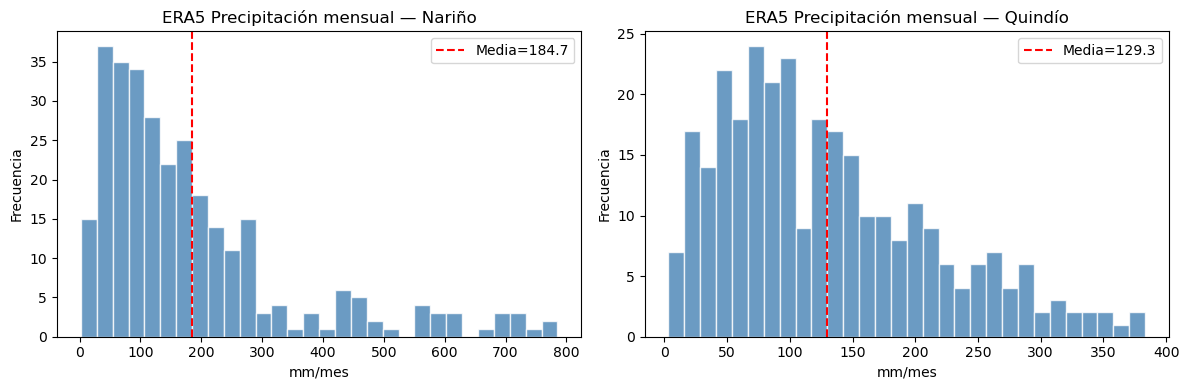

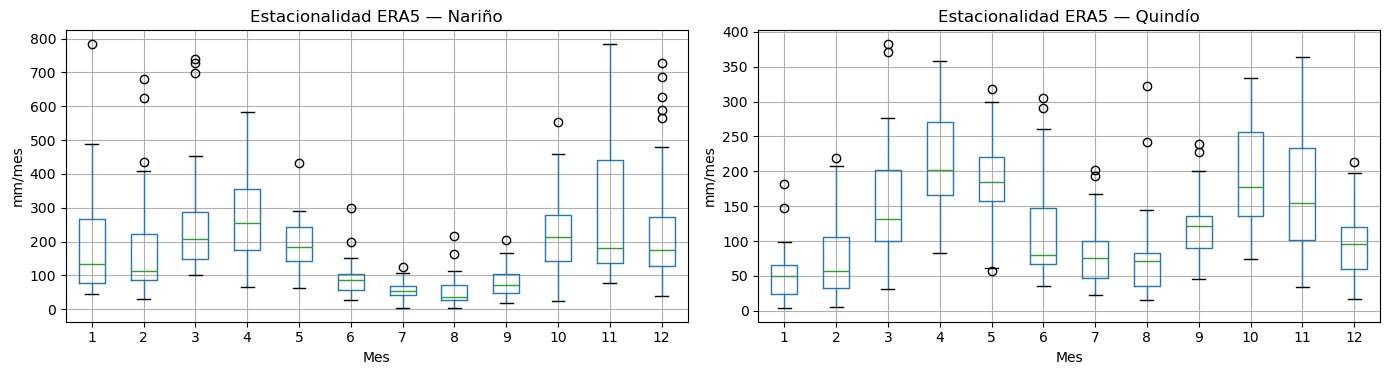

In [6]:
# Descriptivo ERA5 -- precipitacion mensual agregada
print('ERA5 — Estadísticas descriptivas por departamento')
print(era5.groupby('departamento')['precip_mm'].describe().round(2).to_string())

# Valores faltantes
print(f'\nValores faltantes en precip_mm: {era5["precip_mm"].isna().sum()}')

# Distribución por
print('\n')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (dept, grp) in zip(axes, era5.groupby('departamento')):
    ax.hist(grp['precip_mm'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(grp['precip_mm'].mean(), color='red', linestyle='--', label=f'Media={grp["precip_mm"].mean():.1f}')
    ax.set_title(f'ERA5 Precipitación mensual — {dept}')
    ax.set_xlabel('mm/mes')
    ax.set_ylabel('Frecuencia')
    ax.legend()
plt.tight_layout()
plt.savefig('/content/outputs/era5_distribucion_precipitacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplot por mes para detectar estacionalidad
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (dept, grp) in zip(axes, era5.groupby('departamento')):
    grp.boxplot(column='precip_mm', by='month', ax=ax)
    ax.set_title(f'Estacionalidad ERA5 — {dept}')
    ax.set_xlabel('Mes')
    ax.set_ylabel('mm/mes')
plt.suptitle('')
plt.tight_layout()
plt.savefig('/content/outputs/era5_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()

### **1.2 EVA -- Rendimiento municipal del café**

Las Evaluaciones Agropecuarias Municipales (EVA) del MADR contienen datos anuales de rendimiento (kg/ha), área cosechada (ha) y producción total (t) por municipio. Son la fuente oficial de estadisticas agricolas en Colombia y la base para medir las perdidas reales que el seguro debe compensar.


In [7]:
# 1.2 EVA rendimiento municipal (actualizado 2007-2024)
eva_raw_api = pd.read_csv(BASE + 'eva_cafe_quindio_narino_actualizado.csv')

# Histórico (2007-2018): columnas con sufijo _ha y _t_ha
# Reciente  (2019-2024): columnas sin sufijo (_ha es NaN, usa rea_cosechada / rendimiento)
eva_raw_api['rendimiento_kg_ha'] = (
    pd.to_numeric(eva_raw_api['rendimiento_t_ha'], errors='coerce')
    .fillna(pd.to_numeric(eva_raw_api['rendimiento'], errors='coerce'))
) * 1000

eva_raw_api['area_cosechada_ha'] = (
    pd.to_numeric(eva_raw_api['rea_cosechada_ha'], errors='coerce')
    .fillna(pd.to_numeric(eva_raw_api['rea_cosechada'], errors='coerce'))
)

eva_raw_api['produccion_t'] = (
    pd.to_numeric(eva_raw_api['producci_n_t'], errors='coerce')
    .fillna(pd.to_numeric(eva_raw_api['producci_n'], errors='coerce'))
)

eva_raw = eva_raw_api[['departamento', 'municipio', 'a_o',
                         'area_cosechada_ha', 'produccion_t', 'rendimiento_kg_ha']].rename(
    columns={'a_o': 'año'}
).copy()

print('Columnas EVA:', eva_raw.columns.tolist())
print('Shape:', eva_raw.shape)
print(eva_raw.dtypes)
print('\nRegistros con rendimiento por año:')
print(eva_raw.groupby('año')['rendimiento_kg_ha'].count().to_string())


Columnas EVA: ['departamento', 'municipio', 'año', 'area_cosechada_ha', 'produccion_t', 'rendimiento_kg_ha']
Shape: (926, 6)
departamento          object
municipio             object
año                    int64
area_cosechada_ha    float64
produccion_t         float64
rendimiento_kg_ha    float64
dtype: object

Registros con rendimiento por año:
año
2007    49
2008    50
2009    51
2010    53
2011    55
2012    53
2013    49
2014    50
2015    50
2016    50
2017    50
2018    50
2019    52
2020    52
2021    52
2022    52
2023    53
2024    53


In [8]:
# Convertir tipos y limpiar
eva = eva_raw.copy()
# Columna año ya normalizada en carga
col_anio = next((c for c in eva.columns if c in ['año','a_o','anno','ano','year']), eva.columns[2])
eva['anio'] = pd.to_numeric(eva[col_anio], errors='coerce')
eva['rendimiento_kg_ha']  = pd.to_numeric(eva['rendimiento_kg_ha'], errors='coerce')
eva['area_cosechada_ha']  = pd.to_numeric(eva['area_cosechada_ha'], errors='coerce')
if 'produccion_t' in eva.columns:
    eva['produccion_t']   = pd.to_numeric(eva['produccion_t'], errors='coerce')

# Normalizar nombre municipio
eva['municipio'] = (
    eva['municipio'].astype(str).str.strip().str.upper()
    .str.replace('Á','A').str.replace('É','E')
    .str.replace('Í','I').str.replace('Ó','O')
    .str.replace('Ú','U').str.replace('Ñ','N')
)

# Normalizar departamento
eva['departamento'] = (
    eva['departamento'].astype(str).str.strip()
    .str.upper()
    .str.replace('Á','A').str.replace('É','E')
    .str.replace('Í','I').str.replace('Ó','O')
    .str.replace('Ú','U').str.replace('Ñ','N')
    .map({'QUINDIO': 'Quindio', 'NARINO': 'Narino'})
)

# Filtrar outliers de rendimiento
n_antes = len(eva)
eva = eva.dropna(subset=['rendimiento_kg_ha', 'anio'])
eva = eva[(eva['rendimiento_kg_ha'] >= 100) & (eva['rendimiento_kg_ha'] <= 6000)]
n_despues = len(eva)

print(f'Filas antes: {n_antes}  ->  Filas despues del filtro: {n_despues}')
print(f'Departamentos: {eva["departamento"].unique()}')
print(f'Anos: {int(eva["anio"].min())} - {int(eva["anio"].max())}')
print(eva.groupby('departamento')['rendimiento_kg_ha'].describe().round(1))

Filas antes: 926  ->  Filas despues del filtro: 922
Departamentos: ['Quindio' 'Narino']
Anos: 2007 - 2024
              count    mean    std    min    25%     50%     75%     max
departamento                                                            
Narino        706.0   988.1  269.4  110.0  820.0  1000.0  1170.0  1900.0
Quindio       216.0  1129.4  223.4  630.0  997.5  1115.0  1260.0  2350.0


#### **Análisis descriptivo — EVA Rendimiento municipal**

Se verifica la distribución del rendimiento (kg/ha) por departamento.
**Shapiro-Wilk** prueba normalidad (H₀: los datos siguen distribución normal).
**Jarque-Bera** prueba conjuntamente asimetría y curtosis (H₀: asimetría=0 y curtosis=3).

EVA — Estadísticas descriptivas por departamento
              count     mean     std    min    25%     50%     75%     max
departamento                                                              
Narino        706.0   988.09  269.36  110.0  820.0  1000.0  1170.0  1900.0
Quindio       216.0  1129.40  223.40  630.0  997.5  1115.0  1260.0  2350.0

Pruebas de normalidad por departamento

Narino (n=706):
  Shapiro-Wilk : W=0.9832, p=0.0000  [No normal al 5%]
  Jarque-Bera  : JB=17.3993, p=0.0002  [Asimétrica o leptocúrtica al 5%]

Quindio (n=216):
  Shapiro-Wilk : W=0.9523, p=0.0000  [No normal al 5%]
  Jarque-Bera  : JB=144.7386, p=0.0000  [Asimétrica o leptocúrtica al 5%]




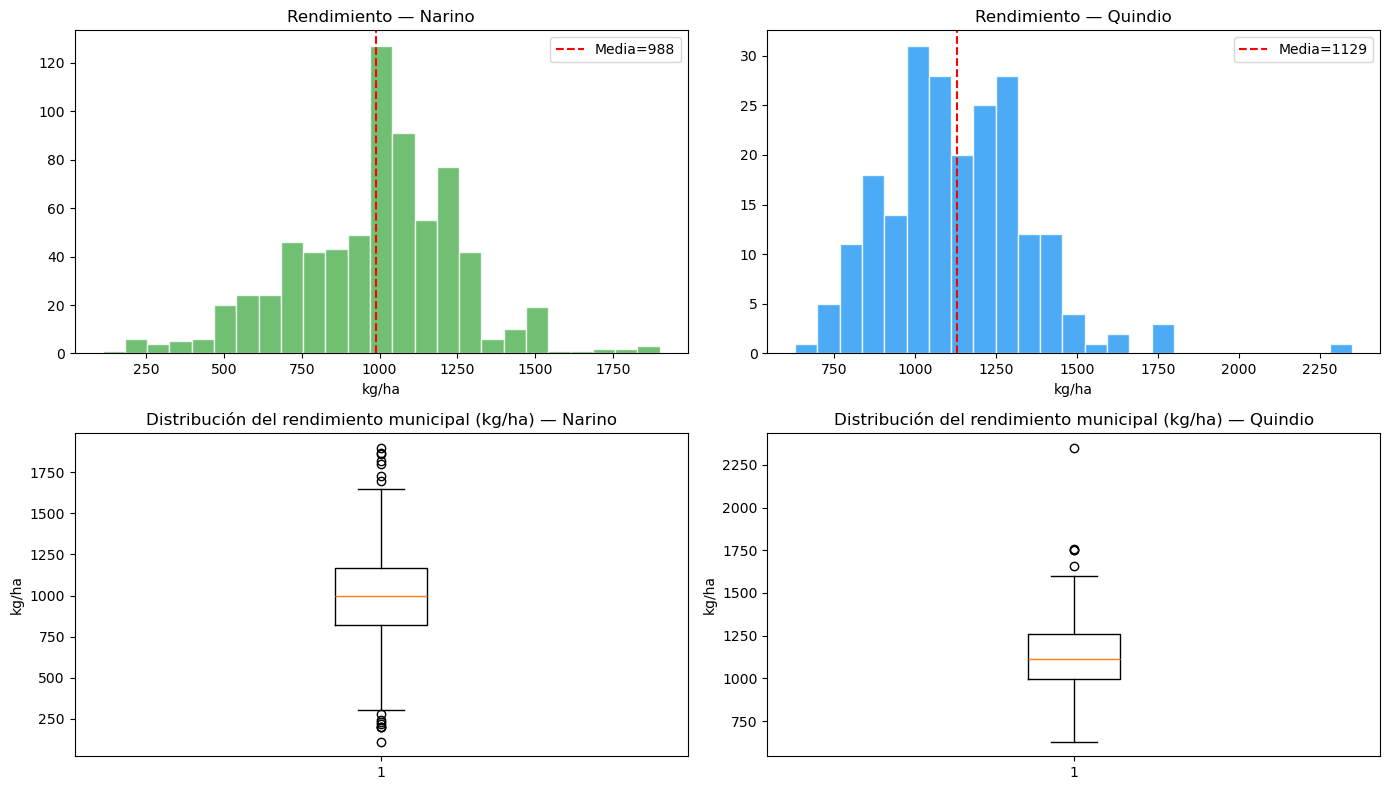

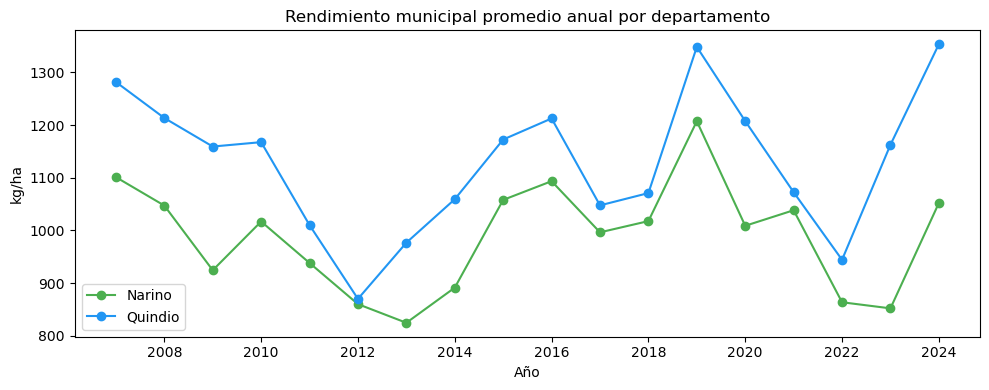

In [9]:
from scipy.stats import shapiro, jarque_bera

print('EVA — Estadísticas descriptivas por departamento')
print(eva.groupby('departamento')['rendimiento_kg_ha'].describe().round(2).to_string())

print('\nPruebas de normalidad por departamento')
for dept, grp in eva.groupby('departamento'):
    vals = grp['rendimiento_kg_ha'].dropna().values
    if len(vals) < 8:
        print(f'{dept}: insuficientes datos (n={len(vals)})')
        continue
    stat_sw, p_sw   = shapiro(vals)
    stat_jb, p_jb   = jarque_bera(vals)
    print(f'\n{dept} (n={len(vals)}):')
    print(f'  Shapiro-Wilk : W={stat_sw:.4f}, p={p_sw:.4f}  '
          f'[{"Normal" if p_sw > 0.05 else "No normal"} al 5%]')
    print(f'  Jarque-Bera  : JB={stat_jb:.4f}, p={p_jb:.4f}  '
          f'[{"Simétrica/mesocúrtica" if p_jb > 0.05 else "Asimétrica o leptocúrtica"} al 5%]')

# Histogramas + boxplots por departamento
print('\n')
deptos_eva = eva['departamento'].unique()
fig, axes = plt.subplots(2, len(deptos_eva), figsize=(7 * len(deptos_eva), 8))
if len(deptos_eva) == 1:
    axes = axes.reshape(2, 1)
for j, dept in enumerate(sorted(deptos_eva)):
    vals = eva[eva['departamento'] == dept]['rendimiento_kg_ha'].dropna()
    axes[0, j].hist(vals, bins=25, color=COLORES.get(dept, 'gray'), edgecolor='white', alpha=0.8)
    axes[0, j].axvline(vals.mean(), color='red', linestyle='--', label=f'Media={vals.mean():.0f}')
    axes[0, j].set_title(f'Rendimiento — {dept}')
    axes[0, j].set_xlabel('kg/ha')
    axes[0, j].legend()
    axes[1, j].boxplot(vals, vert=True)
    axes[1, j].set_title(f'Distribución del rendimiento municipal (kg/ha) — {dept}')
    axes[1, j].set_ylabel('kg/ha')
plt.tight_layout()
plt.savefig('/content/outputs/eva_distribucion_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Serie temporal de rendimiento departamental
fig, ax = plt.subplots(figsize=(10, 4))
for dept, grp in eva.groupby('departamento'):
    anual = grp.groupby('anio')['rendimiento_kg_ha'].mean()
    ax.plot(anual.index, anual.values, marker='o',
            color=COLORES.get(dept, 'gray'), label=dept)
ax.set_title('Rendimiento municipal promedio anual por departamento')
ax.set_xlabel('Año')
ax.set_ylabel('kg/ha')
ax.legend()
plt.tight_layout()
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.savefig('/content/outputs/eva_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### **Rendimiento departamental -- agregado de EVA**

Para modelar el rendimiento a nivel departamental se pondera cada municipio
por su área cosechada (ha). Esto evita que municipios pequeños distorsionen
el promedio y refleja mejor el impacto económico agregado.


In [10]:
# Rendimiento departamental ponderado por área
def rendimiento_ponderado(grp):
    pesos = grp['area_cosechada_ha'].fillna(1)
    return np.average(grp['rendimiento_kg_ha'], weights=pesos)

rend_depto = (
    eva
    .dropna(subset=['area_cosechada_ha'])
    .groupby(['departamento', 'anio'])
    .apply(rendimiento_ponderado)
    .reset_index()
    .rename(columns={0: 'rendimiento_kg_ha', 'anio': 'year'})
)

print('Rendimiento departamental:')
print(rend_depto.head(10))
print(rend_depto.groupby('departamento')[['rendimiento_kg_ha']].describe().round(1))

Rendimiento departamental:
  departamento  year  rendimiento_kg_ha
0       Narino  2007        1298.603786
1       Narino  2008        1221.961068
2       Narino  2009        1039.027468
3       Narino  2010        1045.992513
4       Narino  2011         992.140120
5       Narino  2012        1009.721293
6       Narino  2013         889.648358
7       Narino  2014         961.501294
8       Narino  2015        1093.041388
9       Narino  2016        1130.131908
             rendimiento_kg_ha                                                \
                         count    mean    std    min     25%     50%     75%   
departamento                                                                   
Narino                    18.0  1064.9  117.8  889.6   996.5  1048.2  1120.7   
Quindio                   18.0  1118.9  131.7  854.3  1050.9  1116.4  1199.0   

                      
                 max  
departamento          
Narino        1298.6  
Quindio       1352.3  


### **1.3 IDEAM -- Temperatura y humedad relativa**

El IDEAM (Instituto de Hidrologia, Meteorología y Estudios Ambientales) provee datos de estaciones meteorológicas terrestres. Los archivos están en formato 'ancho' (wide): filas = anio x departamento, columnas = meses (Ene., Feb., ..., Dic.).

La función `parse_ideam` realiza la transformación a formato largo (tidy), convierte los valores faltantes codificados como '(-)' o 'ND', y agrega a nivel anual.


In [11]:
# 1.3 IDEAM -- funcion de parseo generica
def parse_ideam(fname, var_name):
    df = pd.read_excel(BASE + fname)
    # Limpiar nombres de columnas
    df.columns = [str(c).strip().rstrip('.').rstrip(' ') for c in df.columns]

    # Identificar columnas
    id_cols_possible = ['Ano', 'Anno', 'Year', 'Departamento', 'Municipio']
    id_cols = [c for c in df.columns if any(p.lower() in c.lower() for p in
               ['ao', 'ann', 'year', 'depart', 'munic'])]

    # Renombrar columnas de identificacion
    rename_map = {}
    for c in df.columns:
        cl = c.lower()
        if 'ao' in cl or 'year' in cl or cl.startswith('a'):
            if c not in rename_map and 'year' not in rename_map.values():
                rename_map[c] = 'year'
        elif 'depart' in cl:
            rename_map[c] = 'departamento'
        elif 'munic' in cl:
            rename_map[c] = 'municipio'
    df = df.rename(columns=rename_map)

    # Asegurar que Ano/year exista
    if 'year' not in df.columns:
        # intentar con columna que tenga anios
        for c in df.columns:
            sample = df[c].dropna()
            if len(sample) > 0 and pd.to_numeric(sample.head(3), errors='coerce').notna().all():
                first_val = pd.to_numeric(sample.iloc[0])
                if 1990 <= first_val <= 2030:
                    df = df.rename(columns={c: 'year'})
                    break

    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df.dropna(subset=['year'])
    df['year'] = df['year'].astype(int)

    if 'departamento' not in df.columns:
        df['departamento'] = 'Desconocido'
    if 'municipio' not in df.columns:
        df['municipio'] = 'Desconocido'

    # Identificar columnas de mes
    mes_clean_map = {k.rstrip('.'): v for k, v in MESES.items()}
    mes_cols = [c for c in df.columns
                if c not in ('year', 'departamento', 'municipio')
                and (c in MESES or c.rstrip('.') in mes_clean_map)]

    if not mes_cols:
        # Buscar por nombre parcial
        mes_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
        mes_cols = [c for c in df.columns
                    if any(m in c for m in mes_names)]

    # Melt
    df_long = df.melt(
        id_vars=['year', 'departamento', 'municipio'],
        value_vars=mes_cols,
        var_name='mes_str',
        value_name='valor'
    )

    # Mapear mes a número
    df_long['month'] = df_long['mes_str'].str.strip().str.rstrip('.').map(mes_clean_map)

    # Limpiar valor
    df_long['valor'] = (
        df_long['valor']
        .astype(str)
        .str.replace(r'\(-\)', '', regex=True)
        .str.replace('ND', '', regex=False)
        .str.replace(r'[^\d.\-]', '', regex=True)
        .replace('', np.nan)
    )
    df_long['valor'] = pd.to_numeric(df_long['valor'], errors='coerce')

    # Normalizar departamento
    df_long['departamento'] = (
        df_long['departamento']
        .astype(str).str.strip()
        .str.replace('Armenia', 'Quindio', regex=False)
        .str.replace('Aldana', 'Narino', regex=False)
        .str.replace('Quindio', 'Quindio', regex=False)
        .str.replace('Narino', 'Narino', regex=False)
    )

    # Agregar a nivel anual
    agg = (
        df_long
        .groupby(['departamento', 'year'])['valor']
        .agg(mean_val='mean', min_val='min', max_val='max')
        .reset_index()
    )
    agg.columns = ['departamento', 'year',
                   f'{var_name}_mean', f'{var_name}_min', f'{var_name}_max']
    return agg

print('Funcion parse_ideam definida.')

Funcion parse_ideam definida.


In [12]:
# Aplicar parse_ideam a cada variable
tmedia = parse_ideam('df_tmedia_aire.xlsx', 'tmedia')
tmax   = parse_ideam('df_tmax_aire.xlsx',   'tmax')
tmin   = parse_ideam('df_tmin_aire.xlsx',   'tmin')
hr     = parse_ideam('df_hr.xlsx',          'hr')

print('Temperatura media:')
print(tmedia.head())
print(f'Shape: {tmedia.shape}, Deptos: {tmedia["departamento"].unique()}')
print('\n')

print('Temperatura máxima:')
print(tmax.head())
print('\n')

print('Temperatura mínima:')
print(tmin.head())
print('\n')

print('Humedad relativa:')
print(hr.head())

Temperatura media:
  departamento  year  tmedia_mean  tmedia_min  tmedia_max
0       Nariño  1972    11.408333        10.8        12.3
1       Nariño  1973    11.408333        10.7        12.1
2       Nariño  1974    10.558333         9.6        11.4
3       Nariño  1975    10.175000         9.2        10.8
4       Nariño  1976    10.316667         9.2        11.1
Shape: (105, 5), Deptos: ['Nariño' 'Quindio']


Temperatura máxima:
  departamento  year  tmax_mean  tmax_min  tmax_max
0       Nariño  1972  18.440000      17.2      20.0
1       Nariño  1973  19.000000      17.4      20.6
2       Nariño  1974  18.166667      17.0      21.6
3       Nariño  1975  17.741667      16.4      19.4
4       Nariño  1976  18.360000      16.0      20.0


Temperatura mínima:
  departamento  year  tmin_mean  tmin_min  tmin_max
0       Nariño  1972   2.027273       0.0       4.0
1       Nariño  1973   2.044444       0.4       4.8
2       Nariño  1974   2.116667       0.0       5.4
3       Nariño  1975   

#### **Análisis descriptivo — IDEAM (temperatura y humedad relativa)**

Se verifican rangos, valores faltantes y tendencias temporales de las variables
climáticas registradas en estaciones terrestres.

IDEAM — Estadísticas descriptivas

Tmedia:
              count   mean   std    min    25%    50%    75%    max
departamento                                                       
Nariño         53.0  11.10  0.47  10.17  10.76  11.15  11.42  12.21
Quindio        52.0  22.13  0.41  21.28  21.88  22.20  22.38  23.22
  Faltantes: 0

Tmax:
              count   mean   std    min    25%    50%    75%    max
departamento                                                       
Nariño         48.0  18.83  0.62  17.61  18.46  18.82  19.08  20.32
Quindio        51.0  30.76  0.97  29.15  30.24  30.70  31.05  34.90
  Faltantes: 0

Tmin:
              count   mean   std    min    25%    50%    75%    max
departamento                                                       
Nariño         52.0   1.98  0.42   0.77   1.78   2.01   2.19   2.73
Quindio        52.0  14.68  0.79  12.38  14.25  14.74  15.35  15.81
  Faltantes: 0

HR:
              count   mean   std    min    25%    50%    75%    max
departame

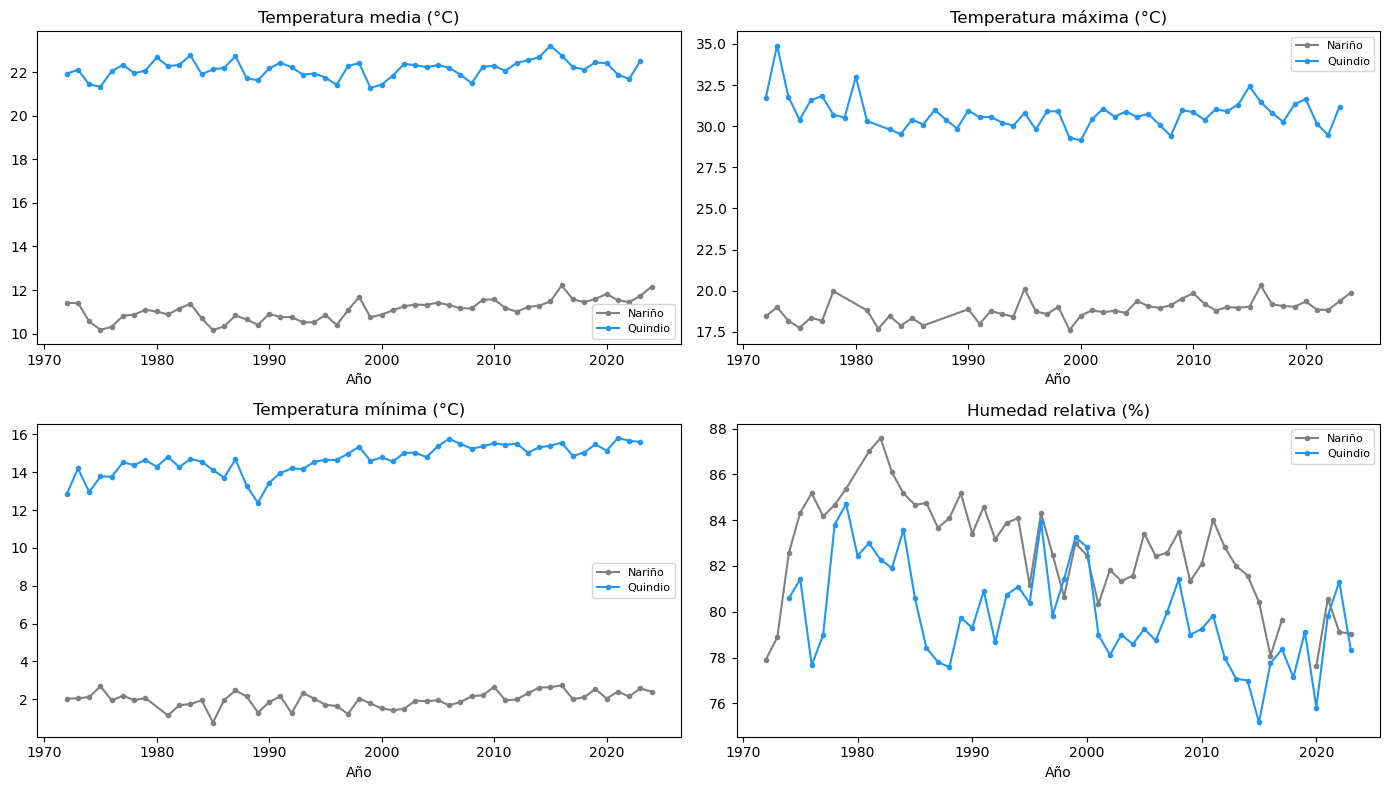

In [13]:
print('IDEAM — Estadísticas descriptivas')
for nombre, df_ideam in [('Tmedia', tmedia), ('Tmax', tmax), ('Tmin', tmin), ('HR', hr)]:
    col_val = [c for c in df_ideam.columns if '_mean' in c][0]
    print(f'\n{nombre}:')
    print(df_ideam.groupby('departamento')[col_val].describe().round(2).to_string())
    print(f'  Faltantes: {df_ideam[col_val].isna().sum()}')

# Series temporales temperatura media
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
vars_ideam = [('Temperatura media (°C)', tmedia, 'tmedia_mean'),
              ('Temperatura máxima (°C)', tmax,   'tmax_mean'),
              ('Temperatura mínima (°C)', tmin,   'tmin_mean'),
              ('Humedad relativa (%)',    hr,      'hr_mean')]
for ax, (titulo, df_v, col) in zip(axes.flat, vars_ideam):
    for dept, grp in df_v.groupby('departamento'):
        grp_sorted = grp.sort_values('year')
        ax.plot(grp_sorted['year'], grp_sorted[col],
                marker='o', markersize=3,
                color=COLORES.get(dept, 'gray'), label=dept)
    ax.set_title(titulo)
    ax.set_xlabel('Año')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/outputs/ideam_series_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

### **1.4 Anomalía de temperatura -- Nariño**

La anomalía de temperatura (desviación respecto al promedio histórico 1981-2010)
es especialmente relevante para Nariño, que tiene mayor variabilidad climática
interanual por su ubicación geográfica cercana al Pacifico sur. Esta variable
captura el efecto del fenómeno El Niño / La Niña en la temperatura.


In [14]:
# 1.4 Anomalía temperatura
def parse_anomalia(fname):
    df = pd.read_excel(BASE + fname)
    df.columns = [str(c).strip() for c in df.columns]

    rename_map = {}
    for c in df.columns:
        cl = c.lower()
        if 'ao' in cl or 'year' in cl:
            if 'year' not in rename_map.values():
                rename_map[c] = 'year'
        elif 'depart' in cl:
            rename_map[c] = 'departamento'
        elif 'munic' in cl:
            rename_map[c] = 'municipio'
    df = df.rename(columns=rename_map)

    if 'year' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'year'})
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df.dropna(subset=['year'])
    df['year'] = df['year'].astype(int)

    if 'departamento' not in df.columns:
        df['departamento'] = 'Narino'
    if 'municipio' not in df.columns:
        df['municipio'] = 'Pasto'

    mes_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    mes_cols = [c for c in df.columns
                if c not in ('year', 'departamento', 'municipio')
                and any(m in c for m in mes_names)]

    df_long = df.melt(
        id_vars=['year', 'departamento', 'municipio'],
        value_vars=mes_cols,
        var_name='mes_str', value_name='valor'
    )

    df_long['valor'] = (
        df_long['valor']
        .astype(str)
        .str.replace(r'\(-\)', '', regex=True)
        .str.replace('ND', '', regex=False)
        .str.replace(r'[^\d.\-]', '', regex=True)
        .replace('', np.nan)
    )
    df_long['valor'] = pd.to_numeric(df_long['valor'], errors='coerce')

    df_long['departamento'] = (
        df_long['departamento']
        .astype(str).str.strip()
        .str.replace('Narino', 'Narino', regex=False)
        .str.replace('Pasto', 'Narino', regex=False)
    )

    agg = (
        df_long
        .groupby(['departamento', 'year'])['valor']
        .agg(mean_val='mean')
        .reset_index()
    )
    agg.columns = ['departamento', 'year', 'anom_temp_mean']
    return agg

anom_temp = parse_anomalia('df_anomalia_temp.xlsx')
print('Anomalía temperatura:')
print(anom_temp.head())
print(f'Shape: {anom_temp.shape}')
print(f'Deptos: {anom_temp["departamento"].unique()}')

Anomalía temperatura:
  departamento  year  anom_temp_mean
0       Nariño  2000       -0.512504
1       Nariño  2001        0.129394
2       Nariño  2002        0.312141
3       Nariño  2003        0.362379
4       Nariño  2004        0.086654
Shape: (25, 3)
Deptos: ['Nariño']


### **1.5 MODIS -- NDVI/EVI anual**

MODIS (Moderate Resolution Imaging Spectroradiometer) es un sensor satélital de NASA que provee indices de vegetacion. El NDVI (Normalized Difference Vegetation Index) refleja la salud y densidad del dosel vegetal. Un NDVI bajo en un año puede indicar estres hidrico o daño por heladas en las plantaciones de café.

El lag de 1 año captura el efecto retardado del estres sobre el rendimiento del año siguiente.


In [15]:
# 1.5 MODIS NDVI/EVI anual
modis_raw = pd.read_csv(BASE + 'df_modis_anual.csv')
print('Columnas MODIS:', modis_raw.columns.tolist())
print('Shape:', modis_raw.shape)
print(modis_raw.head())

Columnas MODIS: ['departamento', 'year', 'ndvi_mean', 'ndvi_min', 'ndvi_max', 'evi_mean', 'evi_min', 'evi_max']
Shape: (16, 8)
  departamento  year  ndvi_mean  ndvi_min  ndvi_max  evi_mean   evi_min  \
0       Narino  2012   0.470871  0.381346  0.588031  0.317624  0.250882   
1       Narino  2013   0.426934  0.365695  0.614330  0.292339  0.232386   
2       Narino  2014   0.468278  0.336115  0.548037  0.322602  0.247661   
3       Narino  2015   0.502860  0.388362  0.593668  0.341148  0.281995   
4       Narino  2016   0.440768  0.322141  0.637424  0.303053  0.222072   

    evi_max  
0  0.398923  
1  0.408850  
2  0.373862  
3  0.383826  
4  0.405136  


In [16]:
# Normalizar nombres departamento
modis = modis_raw.copy()
modis['departamento'] = (modis['departamento']
                         .astype(str).str.strip())

# Crear lag de NDVI
modis = modis.sort_values(['departamento', 'year'])
modis['ndvi_lag1'] = modis.groupby('departamento')['ndvi_mean'].shift(1)

print('MODIS procesado:')
print(modis.head(10))
print(f'Shape: {modis.shape}')
print(f'Deptos: {modis["departamento"].unique()}')

MODIS procesado:
  departamento  year  ndvi_mean  ndvi_min  ndvi_max  evi_mean   evi_min  \
0       Narino  2012   0.470871  0.381346  0.588031  0.317624  0.250882   
1       Narino  2013   0.426934  0.365695  0.614330  0.292339  0.232386   
2       Narino  2014   0.468278  0.336115  0.548037  0.322602  0.247661   
3       Narino  2015   0.502860  0.388362  0.593668  0.341148  0.281995   
4       Narino  2016   0.440768  0.322141  0.637424  0.303053  0.222072   
5       Narino  2017   0.497335  0.343346  0.761902  0.341696  0.248490   
6       Narino  2018   0.449309  0.321113  0.553281  0.309855  0.230988   
7       Narino  2019   0.445566  0.336476  0.557614  0.307140  0.241088   
8      Quindio  2012   0.556838  0.322766  0.770978  0.396176  0.235620   
9      Quindio  2013   0.530212  0.369564  0.759686  0.376831  0.288156   

    evi_max  ndvi_lag1  
0  0.398923        NaN  
1  0.408850   0.470871  
2  0.373862   0.426934  
3  0.383826   0.468278  
4  0.405136   0.502860  
5  0.45

### **1.6 Precios café -- NYMEX KC=F**

El precio internacional del café afecta los ingresos reales del agricultor independientemente del clima. Se usa el contrato de futuros KC=F (café arabica, bolsa de Nueva York) y el tipo de cambio COP/USD para convertir a pesos colombianos. La carga colombiana = 125 kg de cafe pergamino seco, con factor de conversion de ~275.5 kg verde / carga.

Se incluyen lags de 1 y 2 años porque las decisiones de inversión y mantenimiento responden al precio percibido en temporadas anteriores.


In [17]:
# 1.6 Precios café -- Precio Interno FNC (fuente oficial Almacafe/FNC)
# Precio base de compra por carga de 125 kg cafe pergamino seco, en COP.
# Más preciso que NYMEX KC=F: refleja lo que recibe directamente el productor colombiano.
precio_fnc_raw = pd.read_excel(
    BASE + 'Precios-area-y-produccion-de-cafe-2026-3.xlsx',
    sheet_name='2. Precio Interno Mensual',
    skiprows=5, usecols=[3, 4], names=['fecha', 'precio_cop_mensual']
)
precio_fnc_raw = precio_fnc_raw.dropna(subset=['fecha', 'precio_cop_mensual'])
precio_fnc_raw['fecha'] = pd.to_datetime(precio_fnc_raw['fecha'])
precio_fnc_raw['year']  = precio_fnc_raw['fecha'].dt.year

precios_df = (
    precio_fnc_raw
    .groupby('year')['precio_cop_mensual'].mean()
    .reset_index()
    .rename(columns={'precio_cop_mensual': 'precio_cop_carga'})
)
precios_df = precios_df[precios_df['year'] >= 2005].copy()
precios_df = precios_df.sort_values('year').reset_index(drop=True)
precios_df['precio_lag1'] = precios_df['precio_cop_carga'].shift(1)
precios_df['precio_lag2'] = precios_df['precio_cop_carga'].shift(2)

print('Precios internos FNC (COP/carga 125 kg):')
print(precios_df[precios_df['year'].between(2007, 2024)].to_string())
print(f'Shape: {precios_df.shape}')


Precios internos FNC (COP/carga 125 kg):
    year  precio_cop_carga   precio_lag1   precio_lag2
2   2007      4.574626e+05  4.659265e+05  4.570698e+05
3   2008      4.937594e+05  4.574626e+05  4.659265e+05
4   2009      6.579825e+05  4.937594e+05  4.574626e+05
5   2010      7.546732e+05  6.579825e+05  4.937594e+05
6   2011      9.760236e+05  7.546732e+05  6.579825e+05
7   2012      6.605893e+05  9.760236e+05  7.546732e+05
8   2013      4.663736e+05  6.605893e+05  9.760236e+05
9   2014      7.026340e+05  4.663736e+05  6.605893e+05
10  2015      7.164232e+05  7.026340e+05  4.663736e+05
11  2016      8.298270e+05  7.164232e+05  7.026340e+05
12  2017      8.181476e+05  8.298270e+05  7.164232e+05
13  2018      7.411053e+05  8.181476e+05  8.298270e+05
14  2019      7.874726e+05  7.411053e+05  8.181476e+05
15  2020      1.048184e+06  7.874726e+05  7.411053e+05
16  2021      1.519808e+06  1.048184e+06  7.874726e+05
17  2022      2.151004e+06  1.519808e+06  1.048184e+06
18  2023      1.628069e+

### **1.7 Área de café departamental (FNC)**

**Fuente:** `detalle_agricola_departamental_cafe.csv`. Hectareas cosechadas y sembradas  departamento (Quindio y Nariño, 2007-2024). La variable `pct_area_cosechada`(cosechada/sembrada) captura la intensidad productiva, años con sequias o plagas tienden a mostrar menor aprovechamiento del área sembrada.


In [18]:
# 1.7 Área de café departamental (FNC)
def parse_num_es(s):
    """Convierte numero en formato europeo: '24.458,50' -> 24458.50"""
    if pd.isna(s): return np.nan
    return float(str(s).strip().replace('.', '').replace(',', '.'))

area_raw = pd.read_csv(BASE + 'detalle_agricola_departamental_cafe.csv')
area_df  = area_raw.copy()
area_df.columns = [c.strip() for c in area_df.columns]
area_df['departamento'] = (
    area_df['Departamento'].str.strip().str.title()
    .replace({'Nario': 'Narino', 'Nariño': 'Narino',
              'Quindío': 'Quindio', 'Quindio': 'Quindio'})
)
area_df['year']               = area_df['Año'].astype(int)
area_df['area_cosechada_ha']  = area_df['Área Cosechada'].apply(parse_num_es)
area_df['area_sembrada_ha']   = area_df['Área Sembrada'].apply(parse_num_es)
area_df['pct_area_cosechada'] = area_df['area_cosechada_ha'] / area_df['area_sembrada_ha']
area_df = area_df[['departamento','year',
                    'area_cosechada_ha','area_sembrada_ha','pct_area_cosechada']]

print('Área café departamental (FNC):')
print(area_df.to_string())
print(f"Shape: {area_df.shape}  |  Anos: {area_df['year'].min()}-{area_df['year'].max()}")


Área café departamental (FNC):
   departamento  year  area_cosechada_ha  area_sembrada_ha  pct_area_cosechada
0        Narino  2007           24458.50          28331.50            0.863297
1       Quindio  2007           19904.00          23568.47            0.844518
2        Narino  2008           25582.00          30219.50            0.846539
3       Quindio  2008           19571.00          23213.16            0.843099
4        Narino  2009           26467.20          31590.25            0.837828
5       Quindio  2009           19052.00          22862.25            0.833339
6        Narino  2010           23504.05          31969.40            0.735205
7       Quindio  2010           18159.00          22440.45            0.809208
8        Narino  2011           24263.80          34420.80            0.704917
9       Quindio  2011           20139.30          31079.50            0.647993
10       Narino  2012           27806.40          36994.40            0.751638
11      Quindio  2012

### **1.8 MODIS -- NDVI mensual con ventanas fenológicas**

**Fuente:** `df_modis_mensual.csv`. NDVI/EVI mensual 2012-2019. Se calculan medias por ventana fenológica del café: **floración** (abr-may, oct-nov),
**desarrollo** (may-ago), **cosecha** (oct-dic). Estas variables son más informativas que el NDVI anual porque capturan el estado del cultivo en momentos criticos del ciclo.


In [19]:
# 1.8 MODIS -- NDVI/EVI mensual con ventanas fenológicas (2012-2019)
modis_mensual_raw = pd.read_csv(BASE + 'df_modis_mensual.csv')

FL_MESES = [4, 5, 10, 11]   # Floración
DE_MESES = [5, 6, 7,  8]    # Desarrollo del fruto
CO_MESES = [10, 11, 12]     # Cosecha

ndvi_flor = (
    modis_mensual_raw[modis_mensual_raw['month'].isin(FL_MESES)]
    .groupby(['departamento','year'])['ndvi_mean'].mean().reset_index()
    .rename(columns={'ndvi_mean':'ndvi_floracion'})
)
ndvi_desa = (
    modis_mensual_raw[modis_mensual_raw['month'].isin(DE_MESES)]
    .groupby(['departamento','year'])['ndvi_mean'].mean().reset_index()
    .rename(columns={'ndvi_mean':'ndvi_desarrollo_ndvi'})
)
ndvi_cose = (
    modis_mensual_raw[modis_mensual_raw['month'].isin(CO_MESES)]
    .groupby(['departamento','year'])['ndvi_mean'].mean().reset_index()
    .rename(columns={'ndvi_mean':'ndvi_cosecha'})
)
evi_ag = (
    modis_mensual_raw
    .groupby(['departamento','year'])['evi_mean'].mean().reset_index()
    .rename(columns={'evi_mean':'evi_anual'})
)

modis_fenol = (
    ndvi_flor
    .merge(ndvi_desa,  on=['departamento','year'])
    .merge(ndvi_cose,  on=['departamento','year'])
    .merge(evi_ag,     on=['departamento','year'])
)
modis_fenol['ndvi_floracion_lag1'] = (
    modis_fenol.groupby('departamento')['ndvi_floracion'].shift(1)
)

print('NDVI fenológico por departamento:')
print(modis_fenol.to_string())
print(f"Shape: {modis_fenol.shape}  |  Anos: {modis_fenol['year'].min()}-{modis_fenol['year'].max()}")


NDVI fenológico por departamento:
   departamento  year  ndvi_floracion  ndvi_desarrollo_ndvi  ndvi_cosecha  evi_anual  ndvi_floracion_lag1
0        Narino  2012        0.472874              0.505608      0.407832   0.319159                  NaN
1        Narino  2013        0.479739              0.403818      0.450020   0.297193             0.472874
2        Narino  2014        0.478969              0.496851      0.466707   0.324164             0.479739
3        Narino  2015        0.531127              0.505647      0.537909   0.341400             0.478969
4        Narino  2016        0.457035              0.453903      0.429491   0.304231             0.531127
5        Narino  2017        0.452246              0.523742      0.414084   0.341508             0.457035
6        Narino  2018        0.451674              0.432974      0.464338   0.310114             0.452246
7        Narino  2019        0.443691              0.466845      0.417978   0.308229             0.451674
8       Quin

### **1.9 ONI (ENSO) e índice de roya**

El **ONI** (*Oceanic Niño Index*) mide la anomalía de temperatura del mar en la región Niño 3.4 (Pacífico ecuatorial central). Valores positivos = El Niño (sequía en Andes); negativos = La Niña (lluvias excesivas). Es el principal predictor de variabilidad climática interanual en Colombia.

La variable **`roya`** codifica la epidemia de *Hemileia vastatrix* de 2013, que destruyó hasta el 40% del área cafetera colombiana en Nariño. Es un choque fitosanitario documentado que el SPI-3 no puede capturar solo con lluvia.

In [20]:
# 1.9 ONI (ENSO) + variable roya
# ONI: Oceanic Nino Index (NOAA CPC)
# Cargado desde archivo local descargado de NOAA (noaa_oni_index.csv)

try:
    oni_raw = pd.read_csv(BASE + 'noaa_oni_index.csv')
    oni_raw.columns = [c.upper() for c in oni_raw.columns]
    oni_raw['YR']   = pd.to_numeric(oni_raw['YR'],   errors='coerce')
    oni_raw['ANOM'] = pd.to_numeric(oni_raw['ANOM'], errors='coerce')
    oni_anual = (oni_raw.groupby('YR')['ANOM']
                 .agg(oni_mean='mean', oni_max='max', oni_min='min')
                 .reset_index().rename(columns={'YR': 'year'}))
    print(f'ONI cargado localmente: {int(oni_anual.year.min())}-{int(oni_anual.year.max())}')
    ONI_OK = True
except Exception as e:
    print(f'Error leyendo ONI local ({e}). Usando fallback hardcoded.')
    ONI_FALLBACK = {
        'year':     [2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,
                     2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,
                     2020,2021,2022,2023,2024],
        'oni_mean': [-0.55,-0.45, 0.84, 0.41, 0.44, 0.48, 0.53,-0.31,-0.75, 0.59,
                     -1.37,-0.96, 0.22, 0.06, 0.42, 1.24, 0.53,-0.38, 0.53, 0.68,
                      0.53,-0.70,-0.92, 1.26, 0.70],
    }
    oni_anual = pd.DataFrame(ONI_FALLBACK)
    oni_anual['oni_max'] = oni_anual['oni_mean']
    oni_anual['oni_min'] = oni_anual['oni_mean']
    ONI_OK = False

oni_anual = oni_anual.sort_values('year').reset_index(drop=True)
oni_anual['oni_mean_lag1'] = oni_anual['oni_mean'].shift(1)

print('\nONI 2007-2024:')
print(oni_anual[oni_anual['year'].between(2007,2024)][['year','oni_mean']].to_string(index=False))

# Variable roya (Hemileia vastatrix)
roya_df = pd.DataFrame([
    {'departamento': 'Narino',  'year': 2012, 'roya': 0.4},
    {'departamento': 'Narino',  'year': 2013, 'roya': 1.0},
    {'departamento': 'Narino',  'year': 2014, 'roya': 0.3},
    {'departamento': 'Quindio', 'year': 2013, 'roya': 0.6},
])
print('\nVariable roya:')
print(roya_df.to_string(index=False))


ONI cargado localmente: 1950-2026

ONI 2007-2024:
 year  oni_mean
 2007 -0.607500
 2008 -0.781667
 2009  0.281667
 2010 -0.475000
 2011 -0.775000
 2012 -0.063333
 2013 -0.234167
 2014  0.205000
 2015  1.548333
 2016  0.423333
 2017 -0.115000
 2018  0.094167
 2019  0.575000
 2020 -0.271667
 2021 -0.635000
 2022 -0.850000
 2023  0.900000
 2024  0.436667

Variable roya:
departamento  year  roya
      Narino  2012   0.4
      Narino  2013   1.0
      Narino  2014   0.3
     Quindio  2013   0.6


## **2. Track A -- Indice Climático SPI-3**

### ¿Qué es el SPI-3?

El **Standardized Precipitation Index (SPI)** es el estandar internacional (WMO 2012) para caracterizar sequias y excesos hidricos. La escala '3' significa que se usan **ventanas moviles de 3 meses**: el SPI del mes *t* resume las condiciones de precipitacion de los meses *t-2, t-1, t*.

**Interpretacion:**
- SPI < -1.0 => Sequia moderada a severa
- -1.0 <= SPI <= 1.0 => Condiciones normales
- SPI > 1.0 => Exceso hidrico

**¿Por qué SPI-3 para café?**
El café es sensible al deficit hidrico durante la **floración** (oct-nov) y el
**llenado de fruto** (mar-may). Una ventana de 3 meses captura bien estos periodos criticos sin enmascarar variabilidad intraestacional.

**Metodologia McKee et al. (1993):**
1. Calcular precipitación acumulada de 3 meses
2. Ajustar una distribución Gamma por cada mes calendario
3. Transformar a distribución normal estandar => SPI


### **2.1 Verificación de supuesto — Bondad de ajuste Gamma para SPI-3**

El SPI-3 asume que la precipitación acumulada de 3 meses sigue una distribución **Gamma** para cada mes calendario y departamento. Se verifica este supuesto con:

- **Kolmogorov-Smirnov (KS)**: contrasta la CDF empírica vs. la Gamma ajustada (H₀: los datos siguen la distribución Gamma).
- **Q-Q plot**: inspección visual del ajuste en las colas.
- **Histograma vs. densidad Gamma**: verificación visual por departamento para los meses más críticos (meses de mayor volumen hídrico).

In [21]:
# 2.1 Funcion SPI-3 con ajuste Gamma por mes calendario
def add_spi3(df):
    df = df.copy().sort_values(['departamento', 'year', 'month']).reset_index(drop=True)

    # Precipitacion acumulada de 3 meses
    df['precip_3m'] = (df.groupby('departamento')['precip_mm']
                         .transform(lambda x: x.rolling(3, min_periods=3).sum()))

    spi_vals = np.full(len(df), np.nan)

    for dept in df['departamento'].unique():
        for mes in range(1, 13):
            mask = (df['departamento'] == dept) & (df['month'] == mes)
            vals = df.loc[mask, 'precip_3m'].dropna().values

            if len(vals) < 4:
                continue

            nonzero = vals[vals > 0]
            if len(nonzero) < 4:
                continue

            try:
                a, loc_p, scale = gamma_dist.fit(nonzero, floc=0)
                p_zero = (len(vals) - len(nonzero)) / len(vals)
                cdf_v = p_zero + (1 - p_zero) * gamma_dist.cdf(vals, a, loc=0, scale=scale)
                eps = 1e-6
                cdf_v = np.clip(cdf_v, eps, 1 - eps)
                spi_tmp = norm_dist.ppf(cdf_v)
                idx_valid = df.loc[mask].dropna(subset=['precip_3m']).index
                spi_vals[idx_valid] = spi_tmp
            except Exception:
                pass

    df['spi3'] = spi_vals
    return df

print('Función add_spi3 definida.')

Función add_spi3 definida.


In [22]:
# Calcular SPI-3
era5_spi = add_spi3(era5)

print('SPI-3 calculado:')
print(f'  NaN en spi3: {era5_spi["spi3"].isna().sum()} de {len(era5_spi)}')
print(f'  SPI-3 media: {era5_spi["spi3"].mean():.3f}  std: {era5_spi["spi3"].std():.3f}')
print(era5_spi.head(12))

SPI-3 calculado:
  NaN en spi3: 4 de 600
  SPI-3 media: -0.003  std: 1.000
   departamento  year  month   precip_mm   precip_3m      spi3
0        Nariño  2000      1   63.719707         NaN       NaN
1        Nariño  2000      2   88.575475         NaN       NaN
2        Nariño  2000      3  148.726603  301.021785 -0.879218
3        Nariño  2000      4  153.491344  390.793423 -0.924932
4        Nariño  2000      5  167.357689  469.575636 -0.840165
5        Nariño  2000      6  131.160133  452.009166 -0.437115
6        Nariño  2000      7    2.163776  300.681597 -0.248025
7        Nariño  2000      8   29.451008  162.774917 -0.597848
8        Nariño  2000      9  104.901811  136.516596 -0.976000
9        Nariño  2000     10   96.452942  230.805762 -1.019919
10       Nariño  2000     11   78.940046  280.294800 -1.250285
11       Nariño  2000     12   48.895728  224.288717 -1.621355


Bondad de ajuste Gamma — Precipitación acumulada 3 meses (SPI-3)

Nariño: 12/12 meses aceptan H₀ Gamma (p>0.05)

Quindío: 12/12 meses aceptan H₀ Gamma (p>0.05)

Detalle por mes y departamento:
departamento  mes  n  alpha  scale     KS  p_valor  H0_aceptada
      Nariño    1 24  2.399 309.98 0.2487   0.0857         True
      Nariño    2 24  2.160 303.01 0.2410   0.1036         True
      Nariño    3 25  2.404 281.50 0.2263   0.1316         True
      Nariño    4 25  3.562 210.63 0.2315   0.1162         True
      Nariño    5 25  5.339 139.51 0.1488   0.5860         True
      Nariño    6 25  7.063  79.78 0.1220   0.8083         True
      Nariño    7 25  9.235  36.73 0.1259   0.7776         True
      Nariño    8 25  8.476  24.81 0.1554   0.5315         True
      Nariño    9 25 10.405  18.72 0.1469   0.6015         True
      Nariño   10 25  7.390  49.17 0.1369   0.6868         True
      Nariño   11 25  4.445 134.42 0.2085   0.1974         True
      Nariño   12 25  3.115 250.71 0.23

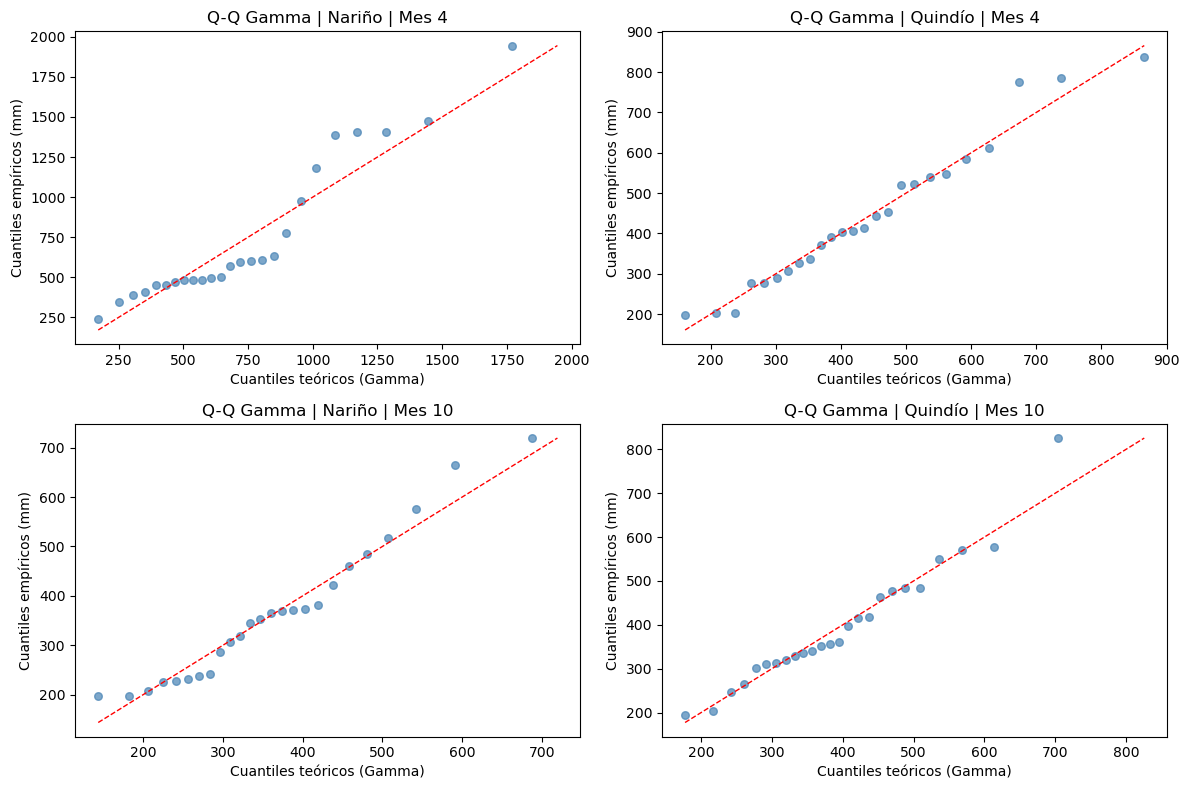

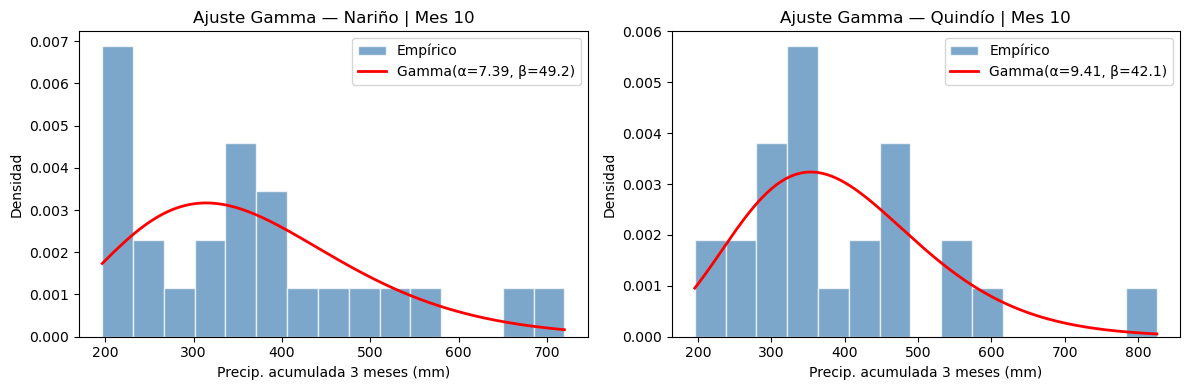

In [23]:
from scipy.stats import kstest, gamma as gamma_dist
import warnings

print('Bondad de ajuste Gamma — Precipitación acumulada 3 meses (SPI-3)')

resultados_ks = []

for dept in sorted(era5_spi['departamento'].unique()):
    sub = era5_spi[era5_spi['departamento'] == dept].copy()
    rechazos = 0
    total    = 0
    for mes in range(1, 13):
        vals = sub[sub['month'] == mes]['precip_3m'].dropna().values
        nonzero = vals[vals > 0]
        if len(nonzero) < 6:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            a, loc_p, scale = gamma_dist.fit(nonzero, floc=0)
        stat, p_val = kstest(nonzero, 'gamma', args=(a, loc_p, scale))
        aprueba = p_val > 0.05
        if not aprueba:
            rechazos += 1
        total += 1
        resultados_ks.append({'departamento': dept, 'mes': mes,
                               'n': len(nonzero), 'alpha': round(a, 3),
                               'scale': round(scale, 2),
                               'KS': round(stat, 4), 'p_valor': round(p_val, 4),
                               'H0_aceptada': aprueba})
    print(f'\n{dept}: {total - rechazos}/{total} meses aceptan H₀ Gamma (p>0.05)')

df_ks = pd.DataFrame(resultados_ks)
print('\nDetalle por mes y departamento:')
print(df_ks.to_string(index=False))

# Q-Q plots para los meses de mayor precipitacion (mes 4 y 10 típicamente)
print('\n')
from scipy.stats import probplot
meses_qq = [4, 10]
fig, axes = plt.subplots(len(meses_qq), 2,
                          figsize=(12, 4 * len(meses_qq)))
for row, mes in enumerate(meses_qq):
    for col, dept in enumerate(sorted(era5_spi['departamento'].unique())):
        sub  = era5_spi[(era5_spi['departamento'] == dept) &
                         (era5_spi['month'] == mes)]
        vals = sub['precip_3m'].dropna().values
        vals = vals[vals > 0]
        if len(vals) < 4:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            a, loc_p, scale = gamma_dist.fit(vals, floc=0)
        ax = axes[row, col]
        # Quantiles teóricos vs empíricos
        sorted_vals = np.sort(vals)
        n = len(sorted_vals)
        probs = (np.arange(1, n + 1) - 0.5) / n
        q_teo = gamma_dist.ppf(probs, a, loc=loc_p, scale=scale)
        ax.scatter(q_teo, sorted_vals, alpha=0.7,
                   color=COLORES.get(dept, 'steelblue'), s=30)
        lims = [min(q_teo.min(), sorted_vals.min()),
                max(q_teo.max(), sorted_vals.max())]
        ax.plot(lims, lims, 'r--', linewidth=1)
        ax.set_title(f'Q-Q Gamma | {dept} | Mes {mes}')
        ax.set_xlabel('Cuantiles teóricos (Gamma)')
        ax.set_ylabel('Cuantiles empíricos (mm)')
plt.tight_layout()
plt.savefig('/content/outputs/spi3_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Histograma + densidad Gamma para mes de mayor precipitacion por depto
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mes_ref = 10  # Octubre: segundo pico lluvioso
for ax, dept in zip(axes, sorted(era5_spi['departamento'].unique())):
    sub  = era5_spi[(era5_spi['departamento'] == dept) &
                     (era5_spi['month'] == mes_ref)]
    vals = sub['precip_3m'].dropna().values
    vals = vals[vals > 0]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        a, loc_p, scale = gamma_dist.fit(vals, floc=0)
    x_range = np.linspace(vals.min(), vals.max(), 200)
    ax.hist(vals, bins=15, density=True,
            color=COLORES.get(dept, 'steelblue'), alpha=0.7, edgecolor='white',
            label='Empírico')
    ax.plot(x_range, gamma_dist.pdf(x_range, a, loc=loc_p, scale=scale),
            'r-', linewidth=2, label=f'Gamma(α={a:.2f}, β={scale:.1f})')
    ax.set_title(f'Ajuste Gamma — {dept} | Mes {mes_ref}')
    ax.set_xlabel('Precip. acumulada 3 meses (mm)')
    ax.set_ylabel('Densidad')
    ax.legend()
plt.tight_layout()
plt.savefig('/content/outputs/spi3_histograma_gamma.png', dpi=150, bbox_inches='tight')
plt.show()

### **2.2 Clasificación de eventos climáticos**

Usando los umbrales de diseño del seguro, cada mes se clasifica como:
- **Sequia**: SPI-3 menor al umbral inferior del departamento
- **Exceso**: SPI-3 mayor al umbral superior del departamento
- **Normal**: entre los umbrales


In [24]:
# 2.2 Clasificar eventos usando UMBRALES
# Mapear nombres de departamento al dict UMBRALES (sin tilde)
def get_umbral(dept):
    if dept in UMBRALES:
        return UMBRALES[dept]
    # Fallback: buscar coincidencia parcial (sin tilde)
    for k in UMBRALES:
        if k.lower().replace('ñ','n').replace('í','i') == dept.lower().replace('ñ','n').replace('í','i'):
            return UMBRALES[k]
    return {'sequia': -1.0, 'exceso': 1.0}

def clasificar_evento(row):
    spi = row['spi3']
    if pd.isna(spi):
        return np.nan
    umb = get_umbral(row['departamento'])
    if spi <= umb['sequia']:
        return 'sequia'
    elif spi >= umb['exceso']:
        return 'exceso'
    else:
        return 'normal'

era5_spi['evento'] = era5_spi.apply(clasificar_evento, axis=1)

print('Clasificacion de eventos:')
print(era5_spi.groupby(['departamento', 'evento']).size().unstack(fill_value=0))

Clasificacion de eventos:
evento        exceso  normal  sequia
departamento                        
Nariño            53     227      18
Quindío           46     219      33


### **2.3 Frecuencia de activación del seguro**

Para que un seguro sea actuarialmente sostenible, la frecuencia de activación debe estar en un rango razonable. Frecuencias muy altas (>25%) hacen el seguro muy costoso; muy bajas (<15%) lo hacen irrelevante. **Objetivo: 15%-25% de meses con evento.**


In [25]:
# 2.3 Frecuencia de activación
req_n3 = {}
for dept in era5_spi['departamento'].unique():
    sub = era5_spi[era5_spi['departamento'] == dept].dropna(subset=['evento'])
    total  = len(sub)
    sequia = (sub['evento'] == 'sequia').sum()
    exceso = (sub['evento'] == 'exceso').sum()
    freq_s = sequia / total * 100
    freq_e = exceso / total * 100
    freq_t = (sequia + exceso) / total * 100
    req_n3[dept] = {
        'N meses': total,
        'Sequia (%)': round(freq_s, 1),
        'Exceso (%)': round(freq_e, 1),
        'Total eventos (%)': round(freq_t, 1),
        '¿Requerimiento N3 cumplido?': 'Si' if 15 <= freq_t <= 25 else 'No'
    }

df_n3 = pd.DataFrame(req_n3).T
print('Frecuencia de activación:')
print(df_n3.to_string())

Frecuencia de activación:
        N meses Sequia (%) Exceso (%) Total eventos (%) ¿Requerimiento N3 cumplido?
Nariño      298        6.0       17.8              23.8                          Si
Quindío     298       11.1       15.4              26.5                          No


### **2.4 Visualización -- Series temporales SPI-3**

Los graficos muestran la evolución mensual del SPI-3 para cada departamento (2000-2017). Las barras de color rojo indican sequia, violeta indican exceso hidrico. Se sombrean los años del evento El Niño 2015 (uno de los más intensos de la historia reciente).


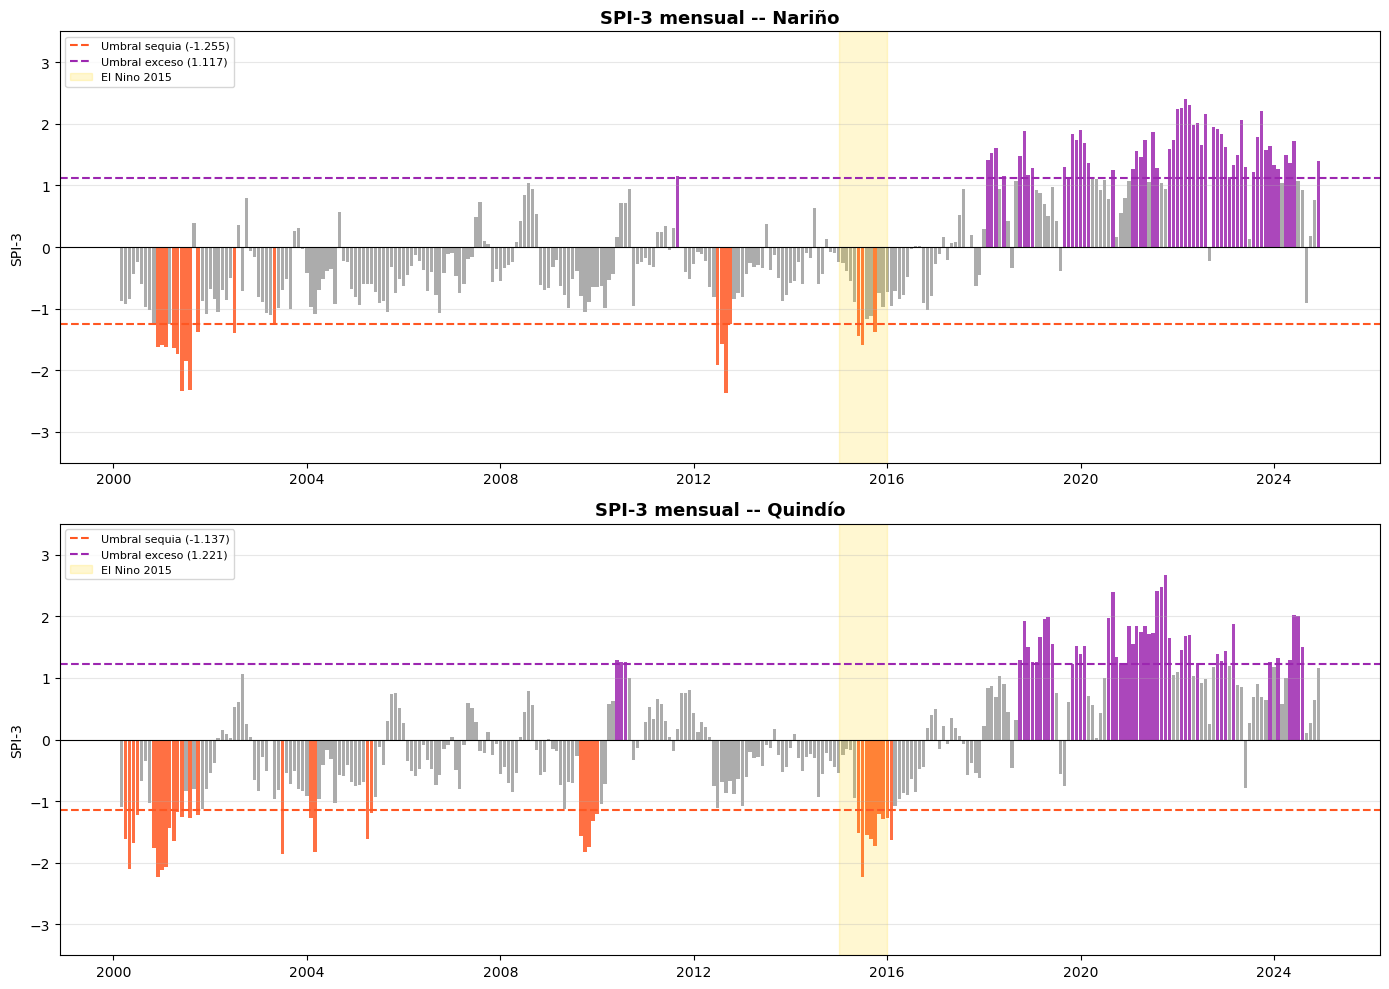

In [26]:
# 2.4 Visualización SPI-3
deptos_spi = era5_spi['departamento'].unique()
fig, axes = plt.subplots(len(deptos_spi), 1, figsize=(14, 5*len(deptos_spi)), sharex=False)
if len(deptos_spi) == 1:
    axes = [axes]

for ax, dept in zip(axes, deptos_spi):
    sub = era5_spi[era5_spi['departamento'] == dept].dropna(subset=['spi3']).copy()
    sub['fecha'] = pd.to_datetime(sub[['year', 'month']].assign(day=1))
    sub = sub.sort_values('fecha')

    colors = sub['evento'].map({
        'sequia' : COLORES['sequia'],
        'exceso' : COLORES['exceso'],
        'normal' : COLORES['normal'],
    }).fillna(COLORES['normal'])

    ax.bar(sub['fecha'], sub['spi3'], color=colors, width=25, alpha=0.85)

    umb = get_umbral(dept)
    ax.axhline(umb['sequia'], color=COLORES['sequia'], lw=1.5, ls='--',
               label=f'Umbral sequia ({umb["sequia"]:.3f})')
    ax.axhline(umb['exceso'], color=COLORES['exceso'], lw=1.5, ls='--',
               label=f'Umbral exceso ({umb["exceso"]:.3f})')
    ax.axhline(0, color='black', lw=0.8)

    ax.axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2016-01-01'),
               alpha=0.18, color=COLORES['elnino'], label='El Nino 2015')

    ax.set_title(f'SPI-3 mensual -- {dept}', fontsize=13, fontweight='bold')
    ax.set_ylabel('SPI-3')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylim(-3.5, 3.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/outputs/spi3_series.png', dpi=150, bbox_inches='tight')
plt.show()

### **2.5 Calibración de umbrales**

Se exige que los umbrales esten basados en la distribucion empirica
de la serie historica, no en valores teóricos fijos. Se analiza la sensibilidad
del percentil de activación entre P10 y P20 (para sequia) y P80-P90 (para exceso).
El equipo técnico selecciono **P12** como el punto de equilibrio entre cobertura y costo.


In [27]:
# 2.5 Calibración de umbrales por percentil empirico
print('Análisis de sensibilidad de umbrales (P10-P20):')

umbrales_calibrados = {}
for dept in era5_spi['departamento'].unique():
    sub = era5_spi[era5_spi['departamento'] == dept]['spi3'].dropna()
    print(f'  {dept}:')
    tabla = []
    for p in [10, 11, 12, 13, 14, 15, 80, 85, 88, 90]:
        val = np.percentile(sub, p)
        if p <= 20:
            freq = (sub <= val).mean() * 100
            tipo = 'sequia'
        else:
            freq = (sub >= val).mean() * 100
            tipo = 'exceso'
        tabla.append({'Percentil': f'P{p}', 'Tipo': tipo,
                       'Umbral SPI': round(val, 3), 'Freq (%)': round(freq, 1)})
    df_tab = pd.DataFrame(tabla)
    print(df_tab.to_string(index=False))

    p_sequia = np.percentile(sub, 12)
    p_exceso = np.percentile(sub, 88)
    umbrales_calibrados[dept] = {'sequia': round(p_sequia, 3), 'exceso': round(p_exceso, 3)}
    print(f'Umbrales calibrados (P12/P88): sequia={p_sequia:.3f}, exceso={p_exceso:.3f}')
    print()

print('Umbrales calibrados finales:')
print(umbrales_calibrados)

# Actualizar UMBRALES
UMBRALES.update(umbrales_calibrados)
# Re-clasificar eventos con umbrales calibrados
era5_spi['evento'] = era5_spi.apply(clasificar_evento, axis=1)
print('UMBRALES actualizados y eventos re-clasificados.')

Análisis de sensibilidad de umbrales (P10-P20):
  Nariño:
Percentil   Tipo  Umbral SPI  Freq (%)
      P10 sequia      -1.032      10.1
      P11 sequia      -0.995      11.1
      P12 sequia      -0.978      12.1
      P13 sequia      -0.961      13.1
      P14 sequia      -0.930      14.1
      P15 sequia      -0.904      15.1
      P80 exceso       1.049      20.1
      P85 exceso       1.265      15.1
      P88 exceso       1.375      12.1
      P90 exceso       1.504      10.1
Umbrales calibrados (P12/P88): sequia=-0.978, exceso=1.375

  Quindío:
Percentil   Tipo  Umbral SPI  Freq (%)
      P10 sequia      -1.207      10.1
      P11 sequia      -1.142      11.1
      P12 sequia      -1.105      12.1
      P13 sequia      -1.060      13.1
      P14 sequia      -0.994      14.1
      P15 sequia      -0.958      15.1
      P80 exceso       0.914      20.1
      P85 exceso       1.233      15.1
      P88 exceso       1.278      12.1
      P90 exceso       1.393      10.1
Umbrales cali

### **2.6 Validacion historica (años malos conocidos)**

Se exige que el indice detecte los dos peores años historicos conocidos:
- **2012**: Epidemia de roya del cafeto (*Hemileia vastatrix*) que redujo la produccion nacional ~30%
- **2015**: El Niño extremo con deficit hidrico severo en toda la zona cafetera

Si el SPI-3 es negativo (sequia) en estos años, el indice tiene validez historica.


In [28]:
# 2.6 Validación años malos 2012 y 2015
print('Validación años conocidos:')
anios_val = [2012, 2015]

for dept in era5_spi['departamento'].unique():
    print(f'  {dept}:')
    for anio in anios_val:
        sub = era5_spi[(era5_spi['departamento'] == dept) & (era5_spi['year'] == anio)]
        if sub.empty:
            print(f'    {anio}: Sin datos')
            continue
        spi_anual = sub['spi3'].mean()
        n_sequia  = (sub['evento'] == 'sequia').sum()
        n_exceso  = (sub['evento'] == 'exceso').sum()
        status = 'detectado' if (n_sequia > 0 or n_exceso > 0) else 'NO detectado'
        print(f'    {anio}: SPI-3 medio = {spi_anual:.3f} | '
              f'Meses sequia = {n_sequia} | Meses exceso = {n_exceso} | {status}')
    print()

Validación años conocidos:
  Nariño:
    2012: SPI-3 medio = -0.904 | Meses sequia = 4 | Meses exceso = 0 | detectado
    2015: SPI-3 medio = -0.895 | Meses sequia = 5 | Meses exceso = 0 | detectado

  Quindío:
    2012: SPI-3 medio = -0.379 | Meses sequia = 1 | Meses exceso = 0 | detectado
    2015: SPI-3 medio = -1.099 | Meses sequia = 7 | Meses exceso = 0 | detectado



### **2.7 Clasificadores de eventos -- Machine Learning**

Se entrenan dos clasificadores para predecir si un mes tendra evento (sequia o exceso) usando caracteristicas climáticas rezagadas. La validación **Leave-One-Year-Out (LOYO)** es la más apropiada para series temporales: se deja fuera un año completo para testear, y se entrena con el resto, rotando sobre todos los años disponibles.


In [29]:
# 2.7 Clasificadores con validacion LOYO
print('Clasificadores de eventos (LOYO):')

# Preparar features
era5_ml = era5_spi.copy()
era5_ml['dept_code']   = (era5_ml['departamento'].str.lower().str.contains('quind')).astype(int)
era5_ml['month_sin']   = np.sin(2 * np.pi * era5_ml['month'] / 12)
era5_ml['month_cos']   = np.cos(2 * np.pi * era5_ml['month'] / 12)

for lag in [1, 2, 3]:
    era5_ml[f'precip_lag{lag}'] = (era5_ml
                                    .groupby('departamento')['precip_mm']
                                    .shift(lag))

era5_ml['evento_bin'] = (era5_ml['evento'] != 'normal').astype(int)
era5_ml = era5_ml.dropna(subset=['spi3', 'precip_lag1', 'precip_lag2', 'precip_lag3'])

FEATS_CLS = ['month_sin', 'month_cos', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'dept_code']

X = era5_ml[FEATS_CLS].values
y = era5_ml['evento_bin'].values
years_arr = era5_ml['year'].values
unique_years = sorted(np.unique(years_arr))

lr_preds, rf_preds, true_labels = [], [], []

for yr in unique_years:
    train_idx = np.where(years_arr != yr)[0]
    test_idx  = np.where(years_arr == yr)[0]
    if len(test_idx) == 0 or len(train_idx) < 10:
        continue

    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    lr = LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced')
    lr.fit(Xtr_s, ytr)
    lr_preds.extend(lr.predict(Xte_s))

    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight='balanced')
    rf.fit(Xtr, ytr)
    rf_preds.extend(rf.predict(Xte))

    true_labels.extend(yte)

print('Logistic Regression:')
print(classification_report(true_labels, lr_preds, target_names=['Normal', 'Evento']))
print(f'F1-macro LR: {f1_score(true_labels, lr_preds, average="macro"):.3f}')
print()
print('Random Forest:')
print(classification_report(true_labels, rf_preds, target_names=['Normal', 'Evento']))
print(f'F1-macro RF: {f1_score(true_labels, rf_preds, average="macro"):.3f}')

Clasificadores de eventos (LOYO):
Logistic Regression:
              precision    recall  f1-score   support

      Normal       0.77      0.63      0.69       450
      Evento       0.26      0.41      0.32       144

    accuracy                           0.58       594
   macro avg       0.52      0.52      0.51       594
weighted avg       0.65      0.58      0.60       594

F1-macro LR: 0.505

Random Forest:
              precision    recall  f1-score   support

      Normal       0.79      0.94      0.86       450
      Evento       0.57      0.23      0.33       144

    accuracy                           0.77       594
   macro avg       0.68      0.59      0.59       594
weighted avg       0.74      0.77      0.73       594

F1-macro RF: 0.594


## **3. Track B -- Modelo de Rendimiento por Departamento**

### ¿Por qué modelar el rendimiento?

El Track A construye el instrumento del seguro (indice SPI-3), pero no prueba que ese
indice este correlacionado con perdidas economicas reales. El Track B cierra esta brecha
modelando el **rendimiento real de café (kg/ha)** en función del clima y otros factores.

Si los modelos muestran que el SPI-3 tiene poder explicativo sobre el rendimiento,
se justifica usar SPI-3 como base del seguro (reduccion del **riesgo base**).

### Variables del modelo

| Grupo | Variables |
|-------|------------|
| Clima SPI-3 | spi3_mean, spi3_min, spi3_floracion, spi3_desarrollo, spi3_cosecha, n_sequia, n_exceso |
| Temperatura IDEAM | tmedia_mean, tmax_mean, tmin_mean, hr_mean |
| Anomalia temp. | anom_temp_mean |
| MODIS | ndvi_mean, ndvi_lag1 |
| Macro | precio_cop_carga, precio_lag1, precio_lag2 |


In [30]:
# 3.1 Agregar SPI-3 mensual a nivel anual con features fenológicas
def spi3_anual_features(df_spi, umb_dict):
    records = []
    for dept in df_spi['departamento'].unique():
        sub = df_spi[df_spi['departamento'] == dept].copy()

        for yr in sub['year'].unique():
            yr_data = sub[sub['year'] == yr]
            spi_vals = yr_data['spi3'].dropna()
            if len(spi_vals) < 6:
                continue

            spi_m    = yr_data.set_index('month')['spi3']
            fl_meses = [4, 5, 10, 11]
            de_meses = [5, 6, 7, 8]
            co_meses = [10, 11, 12]

            rec = {
                'departamento'    : dept,
                'year'            : yr,
                'spi3_mean'       : spi_vals.mean(),
                'spi3_min'        : spi_vals.min(),
                'spi3_floracion'  : spi_m.reindex(fl_meses).mean(),
                'spi3_desarrollo' : spi_m.reindex(de_meses).mean(),
                'spi3_cosecha'    : spi_m.reindex(co_meses).mean(),
                'n_sequia'        : (yr_data['evento'] == 'sequia').sum(),
                'n_exceso'        : (yr_data['evento'] == 'exceso').sum(),
            }
            records.append(rec)

    df_agg = pd.DataFrame(records).sort_values(['departamento', 'year'])

    lag_cols = ['spi3_mean', 'spi3_min', 'spi3_floracion', 'spi3_desarrollo',
                'spi3_cosecha', 'n_sequia', 'n_exceso']
    for col in lag_cols:
        df_agg[f'{col}_lag1'] = df_agg.groupby('departamento')[col].shift(1)

    return df_agg.reset_index(drop=True)

clima_anual = spi3_anual_features(era5_spi, UMBRALES)
print('Clima anual por departamento:')
print(clima_anual.head(10))
print(f'Shape: {clima_anual.shape}')

Clima anual por departamento:
  departamento  year  spi3_mean  spi3_min  spi3_floracion  spi3_desarrollo  \
0       Nariño  2000  -0.879486 -1.621355       -1.008825        -0.530788   
1       Nariño  2001  -1.439775 -2.330366       -1.407156        -2.058208   
2       Nariño  2002  -0.485380 -1.401088       -0.206169        -0.598756   
3       Nariño  2003  -0.651231 -1.272131       -0.450436        -0.867310   
4       Nariño  2004  -0.492934 -1.079002       -0.417335        -0.546184   
5       Nariño  2005  -0.724636 -1.059247       -0.566432        -0.774058   
6       Nariño  2006  -0.468953 -1.073226       -0.464842        -0.427570   
7       Nariño  2007  -0.152849 -0.744385       -0.328936         0.216186   
8       Nariño  2008   0.094328 -0.695992       -0.057958         0.596337   
9       Nariño  2009  -0.658169 -1.057010       -0.843025        -0.664239   

   spi3_cosecha  n_sequia  n_exceso  spi3_mean_lag1  spi3_min_lag1  \
0     -1.297186         3         0      

In [31]:
# 3.2 Construcción del panel integrado
panel = rend_depto.copy()

# Clima SPI-3, se realiza join por departamento
# Primero verificamos los nombres de depto en cada tabla
print('Deptos rend_depto:', rend_depto['departamento'].unique())
print('Deptos clima_anual:', clima_anual['departamento'].unique())
print('Deptos tmedia:', tmedia['departamento'].unique())
print('Deptos modis:', modis['departamento'].unique())

Deptos rend_depto: ['Narino' 'Quindio']
Deptos clima_anual: ['Nariño' 'Quindío']
Deptos tmedia: ['Nariño' 'Quindio']
Deptos modis: ['Narino' 'Quindio']


### EDA consolidado del panel final de modelado

Esta sección consolida la caracterización estadística del panel integrado que será utilizado en el modelado. A diferencia del análisis exploratorio por fuente, este bloque resume la cobertura temporal, completitud, distribución de la variable objetivo y disponibilidad de variables explicativas en el dataset final.

In [32]:
# EDA consolidado del panel integrado

print("EDA FORMAL — Panel integrado para modelado")

# 1. Dimensión general
print("\n1. Dimensión del panel")
print(f"Filas: {panel.shape[0]}")
print(f"Columnas: {panel.shape[1]}")
print(f"Departamentos: {panel['departamento'].nunique()}")
print(f"Años: {panel['year'].min()} - {panel['year'].max()}")

# 2. Observaciones por departamento y año
obs_depto = panel.groupby("departamento").size().reset_index(name="n_observaciones")
obs_year = panel.groupby("year").size().reset_index(name="n_observaciones")

print("\n2. Observaciones por departamento")
display(obs_depto)

print("\n3. Observaciones por año")
display(obs_year)

# 3. Completitud por variable
completitud = (
    panel.notna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"index": "variable", 0: "completitud_pct"})
)

completitud["faltante_pct"] = 100 - completitud["completitud_pct"]

print("\n4. Completitud por variable")
display(completitud.sort_values("faltante_pct", ascending=False))

# 4. Descriptivos de variable objetivo
desc_rend = (
    panel.groupby("departamento")["rendimiento_kg_ha"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(2)
    .reset_index()
)

print("\n5. Estadísticas descriptivas del rendimiento por departamento")
display(desc_rend)

# 5. Descriptivos de variables numéricas principales
num_cols = panel.select_dtypes(include=[np.number]).columns.tolist()
desc_num = panel[num_cols].describe().T.round(3)
desc_num["missing_pct"] = panel[num_cols].isna().mean().mul(100).round(2)

print("\n6. Descriptivos de variables numéricas")
display(desc_num)

# 6. Exportar tablas para el informe
os.makedirs("/content/outputs", exist_ok=True)
completitud.to_csv("/content/outputs/eda_completitud_panel.csv", index=False)
desc_rend.to_csv("/content/outputs/eda_rendimiento_por_departamento.csv", index=False)
desc_num.to_csv("/content/outputs/eda_descriptivos_numericos.csv")

print("\nTablas EDA exportadas en /content/outputs/")

EDA FORMAL — Panel integrado para modelado

1. Dimensión del panel
Filas: 36
Columnas: 3
Departamentos: 2
Años: 2007 - 2024

2. Observaciones por departamento


,departamento,n_observaciones
0,Narino,18
1,Quindio,18



3. Observaciones por año


,year,n_observaciones
0,2007,2
1,2008,2
2,2009,2
3,2010,2
4,2011,2
5,2012,2
6,2013,2
7,2014,2
8,2015,2
9,2016,2



4. Completitud por variable


...


5. Estadísticas descriptivas del rendimiento por departamento


,departamento,count,mean,std,min,median,max
0,Narino,18,1064.85,117.79,889.65,1048.15,1298.60
1,Quindio,18,1118.95,131.65,854.33,1116.45,1352.27



6. Descriptivos de variables numéricas


,count,mean,std,min,25%,50%,75%,max,missing_pct
year,36.0,2015.500,5.262,2007.000,2011.000,2015.500,2020.000,2024.000,0.0
rendimiento_kg_ha,36.0,1091.899,126.133,854.334,1027.721,1067.559,1166.628,1352.274,0.0



Tablas EDA exportadas en /content/outputs/


### Conclusión del EDA consolidado

El panel final de modelado presenta una estructura balanceada y sin valores faltantes, integrando información climática, productiva y de mercado para los departamentos de Quindío y Nariño entre 2007 y 2024.

Sin embargo, el análisis evidencia una limitación estructural importante asociada al tamaño muestral disponible. Aunque el panel contiene 36 observaciones totales, cada departamento dispone únicamente de 18 observaciones temporales, lo que reduce significativamente la potencia estadística y aumenta el riesgo de sobreajuste en modelos de alta complejidad.

Esta restricción resulta especialmente relevante considerando la cantidad de variables climáticas y derivadas evaluadas, evidenciando un escenario de alta dimensionalidad relativa (“curse of dimensionality”). En consecuencia, los resultados del modelado deben interpretarse como una validación técnica preliminar del índice climático y no como evidencia concluyente de capacidad predictiva robusta fuera de muestra.

In [33]:
# Unificar nombres de departamento en todas las tablas
def normalizar_depto(s):
    s = str(s).strip()
    s = s.replace('Nari\u00f1o', 'Narino').replace('Quind\u00edo', 'Quindio')
    s = s.replace('NARINO', 'Narino').replace('NARI\u00d1O', 'Narino')
    s = s.replace('QUINDIO', 'Quindio').replace('QUIND\u00cdO', 'Quindio')
    return s

for df_name, df_obj in [
    ('rend_depto',  rend_depto),  ('clima_anual', clima_anual),
    ('tmedia',      tmedia),      ('tmax',        tmax),
    ('tmin',        tmin),        ('hr',           hr),
    ('anom_temp',   anom_temp),   ('modis',        modis),
    ('area_df',     area_df),     ('modis_fenol',  modis_fenol),
]:
    df_obj['departamento'] = df_obj['departamento'].apply(normalizar_depto)

print('Deptos unificados:')
for nombre in ('rend_depto','clima_anual','area_df','modis_fenol'):
    obj = eval(nombre)
    print(f'  {nombre}: {obj["departamento"].unique().tolist()}')


Deptos unificados:
  rend_depto: ['Narino', 'Quindio']
  clima_anual: ['Narino', 'Quindio']
  area_df: ['Narino', 'Quindio']
  modis_fenol: ['Narino', 'Quindio']


In [34]:
# Merge secuencial -- panel integrado con todas las fuentes
panel = rend_depto.copy()
panel = panel.merge(clima_anual,
                    on=['departamento','year'], how='left')
panel = panel.merge(tmedia[['departamento','year','tmedia_mean']],
                    on=['departamento','year'], how='left')
panel = panel.merge(tmax[['departamento','year','tmax_mean']],
                    on=['departamento','year'], how='left')
panel = panel.merge(tmin[['departamento','year','tmin_mean']],
                    on=['departamento','year'], how='left')
panel = panel.merge(hr[['departamento','year','hr_mean']],
                    on=['departamento','year'], how='left')
panel = panel.merge(anom_temp[['departamento','year','anom_temp_mean']],
                    on=['departamento','year'], how='left')
panel = panel.merge(modis[['departamento','year','ndvi_mean','ndvi_lag1']],
                    on=['departamento','year'], how='left')
panel = panel.merge(
    modis_fenol[['departamento','year',
                 'ndvi_floracion','ndvi_desarrollo_ndvi','ndvi_cosecha',
                 'evi_anual','ndvi_floracion_lag1']],
    on=['departamento','year'], how='left')
panel = panel.merge(
    precios_df[['year','precio_cop_carga','precio_lag1','precio_lag2']],
    on='year', how='left')
panel = panel.merge(
    area_df[['departamento','year',
             'area_cosechada_ha','area_sembrada_ha','pct_area_cosechada']],
    on=['departamento','year'], how='left')

# Quindio no tiene anomalia de temperatura, llenar con 0
panel['anom_temp_mean'] = panel['anom_temp_mean'].fillna(0)

# NDVI fenológico disponible 2012-2019: imputar fuera de ese rango con media departamental
for col in ['ndvi_floracion','ndvi_desarrollo_ndvi','ndvi_cosecha',
            'evi_anual','ndvi_floracion_lag1']:
    panel[col] = panel.groupby('departamento')[col].transform(
        lambda x: x.fillna(x.mean())
    )

print('Panel integrado:')
print(f'  Shape total: {panel.shape}')
print('Cobertura por departamento:')
for dept in panel['departamento'].unique():
    sub = panel[panel['departamento'] == dept]
    n_spi  = sub['spi3_mean'].notna().sum()
    n_tmp  = sub['tmedia_mean'].notna().sum()
    n_mod  = sub['ndvi_mean'].notna().sum()
    n_pre  = sub['precio_cop_carga'].notna().sum()
    n_area = sub['area_cosechada_ha'].notna().sum()
    print(f'  {dept}: {len(sub)} años | SPI={n_spi} | Temp={n_tmp} | NDVI={n_mod} | Precio={n_pre} | Área={n_area}')
print('Columnas panel:', panel.columns.tolist())


Panel integrado:
  Shape total: (36, 35)
Cobertura por departamento:
  Narino: 18 años | SPI=18 | Temp=18 | NDVI=8 | Precio=18 | Área=18
  Quindio: 18 años | SPI=18 | Temp=17 | NDVI=8 | Precio=18 | Área=18
Columnas panel: ['departamento', 'year', 'rendimiento_kg_ha', 'spi3_mean', 'spi3_min', 'spi3_floracion', 'spi3_desarrollo', 'spi3_cosecha', 'n_sequia', 'n_exceso', 'spi3_mean_lag1', 'spi3_min_lag1', 'spi3_floracion_lag1', 'spi3_desarrollo_lag1', 'spi3_cosecha_lag1', 'n_sequia_lag1', 'n_exceso_lag1', 'tmedia_mean', 'tmax_mean', 'tmin_mean', 'hr_mean', 'anom_temp_mean', 'ndvi_mean', 'ndvi_lag1', 'ndvi_floracion', 'ndvi_desarrollo_ndvi', 'ndvi_cosecha', 'evi_anual', 'ndvi_floracion_lag1', 'precio_cop_carga', 'precio_lag1', 'precio_lag2', 'area_cosechada_ha', 'area_sembrada_ha', 'pct_area_cosechada']


#### **Análisis descriptivo — Panel integrado consolidado**

Con el panel completo (ERA5 + EVA + IDEAM + MODIS + ONI) se verifica:

1. **Completitud**: porcentaje de valores faltantes por variable.
2. **Estadísticas descriptivas** del panel final.
3. **Verificación de no-linealidad**: correlación de Spearman entre cada feature y el rendimiento.
   Spearman es apropiado porque no asume linealidad ni normalidad, solo relación monótona.
   Se contrasta con Pearson para evidenciar si la relación es lineal o no.

Panel integrado — Completitud y estadísticas descriptivas

% valores faltantes por variable:
tmedia_mean     2.8
tmax_mean       2.8
tmin_mean       2.8
hr_mean        11.1
ndvi_mean      55.6
ndvi_lag1      61.1

Estadísticas descriptivas del panel:
       spi3_mean  spi3_min  spi3_floracion  spi3_desarrollo  spi3_cosecha  n_sequia  n_exceso  spi3_mean_lag1  spi3_min_lag1  spi3_floracion_lag1  spi3_desarrollo_lag1  spi3_cosecha_lag1  n_sequia_lag1  n_exceso_lag1  tmedia_mean  tmax_mean  tmin_mean  hr_mean  anom_temp_mean  ndvi_mean  ndvi_lag1  ndvi_floracion  ndvi_desarrollo_ndvi  ndvi_cosecha  evi_anual  ndvi_floracion_lag1  precio_cop_carga  precio_lag1  precio_lag2  area_cosechada_ha  area_sembrada_ha  pct_area_cosechada  rendimiento_kg_ha
count      36.00     36.00           36.00            36.00         36.00     36.00     36.00           36.00          36.00                36.00                 36.00              36.00          36.00          36.00        35.00      35.00      

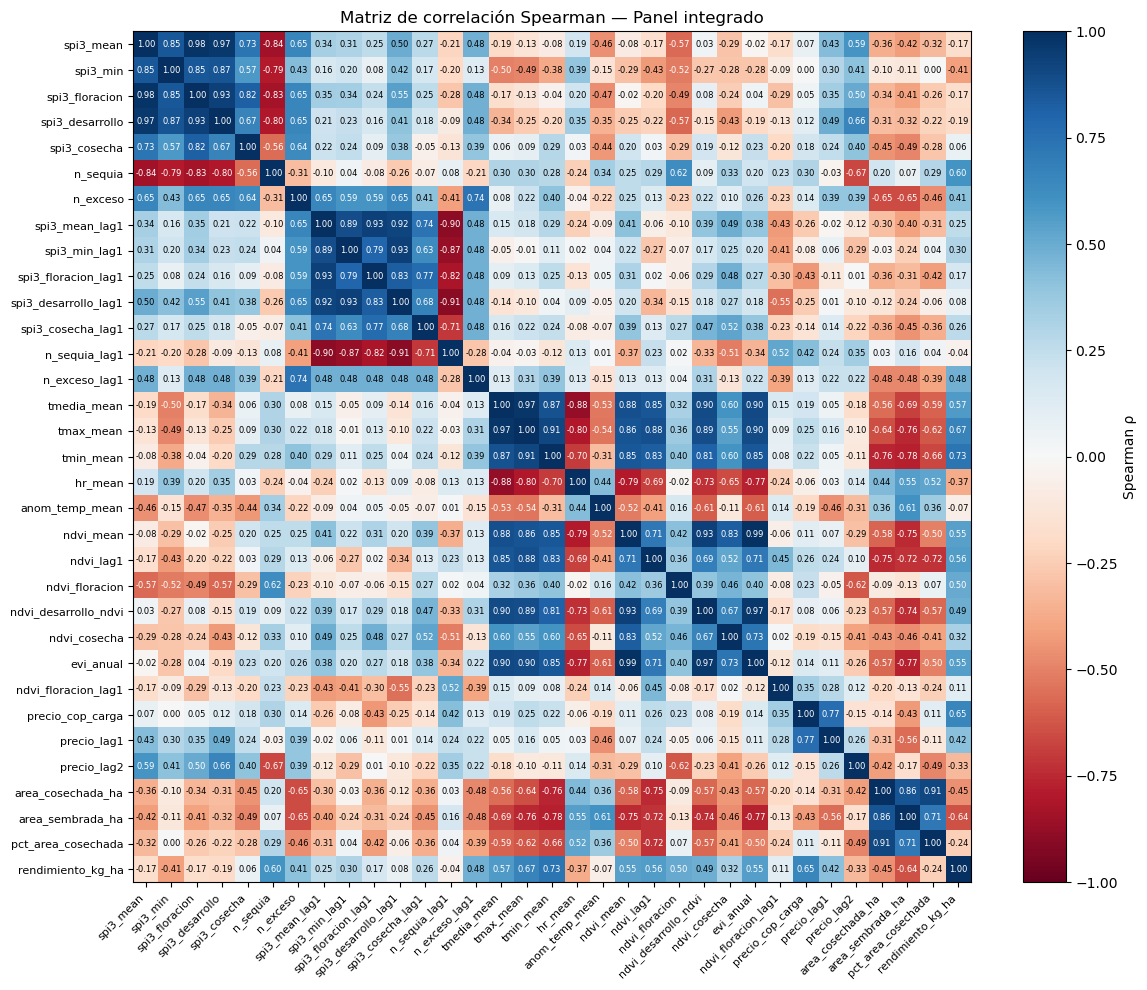

In [35]:
from scipy.stats import spearmanr, pearsonr

print('Panel integrado — Completitud y estadísticas descriptivas')

# Faltantes por variable
faltantes = panel.isnull().mean().round(3) * 100
print('\n% valores faltantes por variable:')
print(faltantes[faltantes > 0].to_string() if (faltantes > 0).any()
      else '  Sin valores faltantes en el panel.')

print('\nEstadísticas descriptivas del panel:')
feat_cols = [c for c in panel.columns
             if c not in ('departamento', 'year', 'rendimiento_kg_ha')]
print(panel[feat_cols + ['rendimiento_kg_ha']].describe().round(2).to_string())

# Spearman vs Pearson por departamento
print('\nCorrelación Spearman vs Pearson con rendimiento_kg_ha')

for dept in sorted(panel['departamento'].unique()):
    sub = panel[panel['departamento'] == dept].dropna(subset=['rendimiento_kg_ha'])
    print(f'\n{dept} (n={len(sub)}):')
    print(f'  {"Variable":<28} {"Spearman":>10} {"Pearson":>10} {"Δ (|Sp|-|Pe|)":>14}')
    print('  ' + '-' * 65)
    filas = []
    for feat in feat_cols:
        pares = sub[['rendimiento_kg_ha', feat]].dropna()
        if len(pares) < 6:
            continue
        sp, p_sp = spearmanr(pares['rendimiento_kg_ha'], pares[feat])
        pe, p_pe = pearsonr(pares['rendimiento_kg_ha'],  pares[feat])
        delta = abs(sp) - abs(pe)
        sig_sp = '*' if p_sp < 0.05 else ' '
        sig_pe = '*' if p_pe < 0.05 else ' '
        filas.append((feat, sp, p_sp, pe, p_pe, delta))
    filas.sort(key=lambda x: abs(x[1]), reverse=True)
    for feat, sp, p_sp, pe, p_pe, delta in filas:
        sig_sp = '*' if p_sp < 0.05 else ' '
        sig_pe = '*' if p_pe < 0.05 else ' '
        print(f'  {feat:<28} {sp:>+8.3f}{sig_sp}  {pe:>+8.3f}{sig_pe}  {delta:>+12.3f}')
    print('  (* p<0.05)\n')

# Heatmap de correlaciones Spearman del panel completo
import matplotlib.colors as mcolors
panel_num = panel[feat_cols + ['rendimiento_kg_ha']].dropna()
corr_sp = panel_num.apply(lambda x: panel_num.apply(
    lambda y: spearmanr(x, y)[0]))
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_sp.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman ρ')
ax.set_xticks(range(len(corr_sp.columns)))
ax.set_yticks(range(len(corr_sp.columns)))
ax.set_xticklabels(corr_sp.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_sp.columns, fontsize=8)
ax.set_title('Matriz de correlación Spearman — Panel integrado')
for i in range(len(corr_sp)):
    for j in range(len(corr_sp.columns)):
        ax.text(j, i, f'{corr_sp.values[i,j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if abs(corr_sp.values[i,j]) > 0.5 else 'black')
plt.tight_layout()
plt.savefig('/content/outputs/panel_correlaciones_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

### **EDA -- Correlaciones con rendimiento**

Antes de modelar, se explora la asociacion lineal de cada feature con el rendimiento.
Correlaciones positivas implican que más precipitación / temperatura / NDVI
se asocia con mayor rendimiento; negativas lo opuesto.


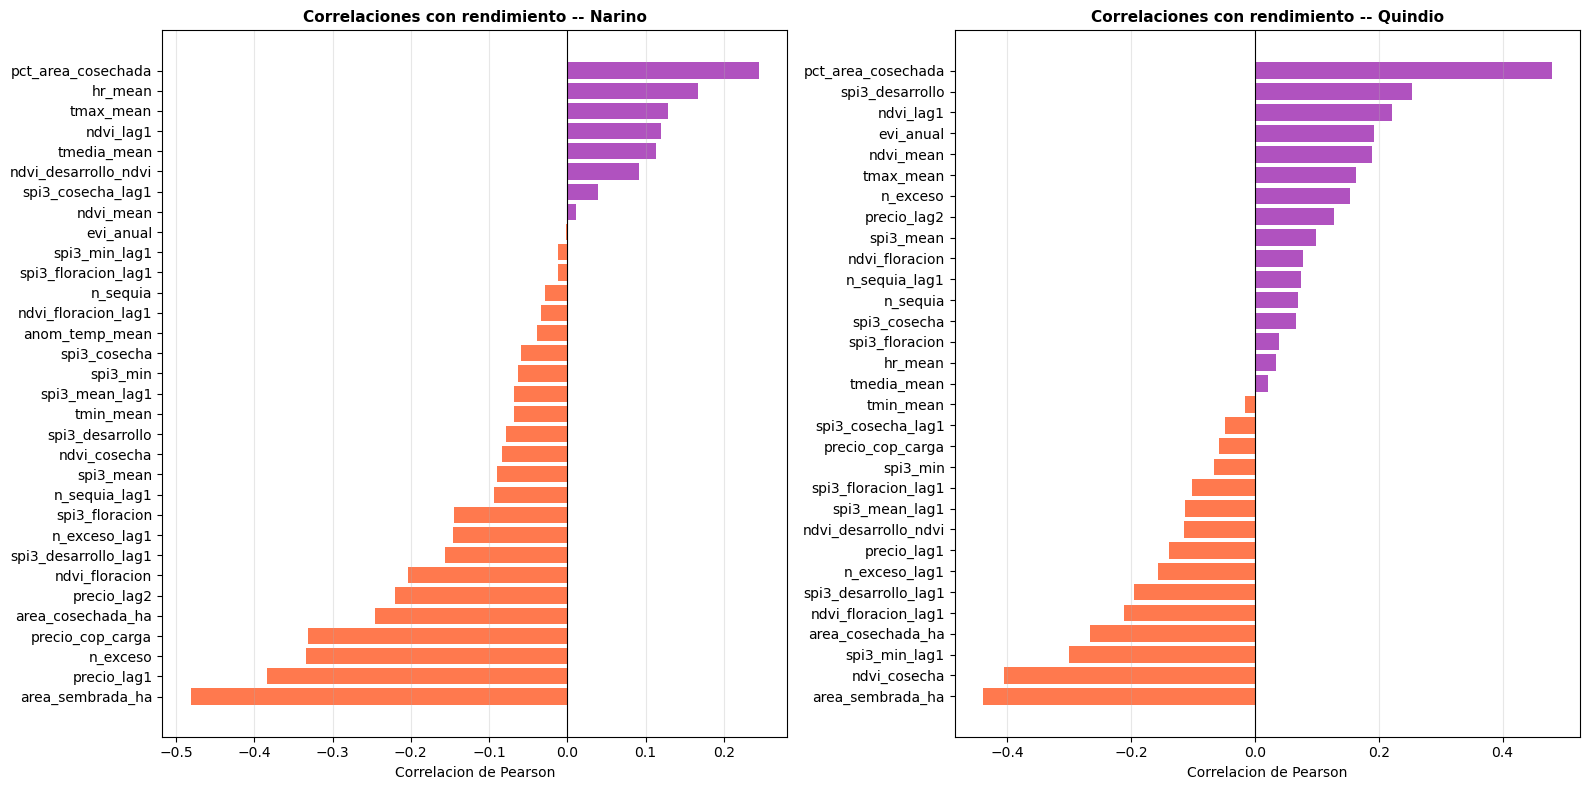

In [36]:
# EDA -- Correlaciones con rendimiento
feat_cols = [c for c in panel.columns if c not in ('departamento', 'year', 'rendimiento_kg_ha')]
deptos_panel = panel['departamento'].unique()

fig, axes = plt.subplots(1, len(deptos_panel), figsize=(8*len(deptos_panel), 8))
if len(deptos_panel) == 1:
    axes = [axes]

for ax, dept in zip(axes, deptos_panel):
    sub = panel[panel['departamento'] == dept][feat_cols + ['rendimiento_kg_ha']].dropna(
        subset=['rendimiento_kg_ha'])
    corrs = sub.corr()['rendimiento_kg_ha'].drop('rendimiento_kg_ha').dropna()
    corrs_sorted = corrs.sort_values()
    colors_bar = [COLORES['exceso'] if v > 0 else COLORES['sequia']
                  for v in corrs_sorted]
    ax.barh(corrs_sorted.index, corrs_sorted.values, color=colors_bar, alpha=0.8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Correlaciones con rendimiento -- {dept}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Correlacion de Pearson')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/outputs/correlaciones_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

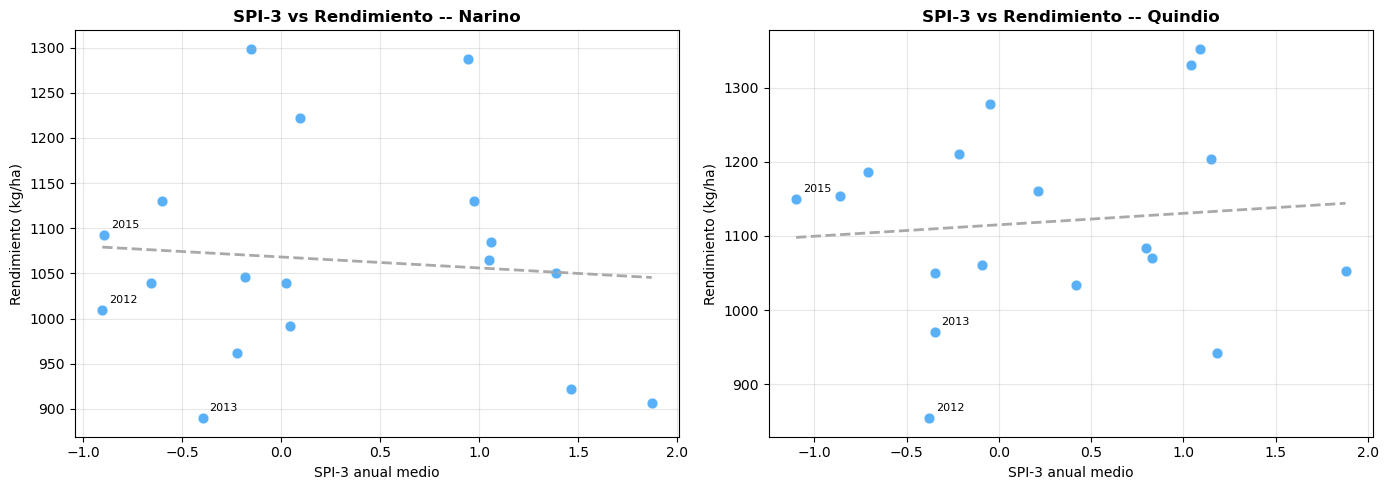

In [37]:
# Scatter SPI-3 vs rendimiento
deptos_panel = panel['departamento'].unique()
fig, axes = plt.subplots(1, len(deptos_panel), figsize=(7*len(deptos_panel), 5))
if len(deptos_panel) == 1:
    axes = [axes]

color_map = {d: list(COLORES.values())[i % len(COLORES)]
             for i, d in enumerate(deptos_panel)}

for ax, dept in zip(axes, deptos_panel):
    sub = panel[panel['departamento'] == dept].dropna(
        subset=['spi3_mean', 'rendimiento_kg_ha'])
    color = color_map[dept]
    ax.scatter(sub['spi3_mean'], sub['rendimiento_kg_ha'],
               color=color, alpha=0.75, s=60, edgecolors='white', lw=0.5)
    if len(sub) > 2:
        z = np.polyfit(sub['spi3_mean'], sub['rendimiento_kg_ha'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(sub['spi3_mean'].min(), sub['spi3_mean'].max(), 50)
        ax.plot(x_line, p(x_line), color='darkgray', lw=2, ls='--')
    for _, row in sub.iterrows():
        if row['year'] in [2012, 2013, 2015]:
            ax.annotate(str(int(row['year'])), (row['spi3_mean'], row['rendimiento_kg_ha']),
                        textcoords='offset points', xytext=(5, 5), fontsize=8)
    ax.set_xlabel('SPI-3 anual medio')
    ax.set_ylabel('Rendimiento (kg/ha)')
    ax.set_title(f'SPI-3 vs Rendimiento -- {dept}', fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/outputs/scatter_spi3_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ============================================================
# Persistir datasets procesados para modelado reproducible
# ============================================================

from pathlib import Path

# Ruta relativa al repositorio:
# notebooks/01_etl_exploracion.ipynb
# -> subir un nivel -> data/processed/

OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Panel departamental consolidado
# ------------------------------------------------------------

panel.to_csv(
    OUT_DIR / "features_modelo.csv",
    index=False
)

print(f"features_modelo.csv guardado: {panel.shape}")

# ------------------------------------------------------------
# EVA municipal
# ------------------------------------------------------------

eva.to_csv(
    OUT_DIR / "eva_municipal.csv",
    index=False
)

print(f"eva_municipal.csv guardado: {eva.shape}")

# ------------------------------------------------------------
# SPI-3 anual con variables fenológicas
# ------------------------------------------------------------

clima_anual.to_csv(
    OUT_DIR / "clima_anual_spi3.csv",
    index=False
)

print(f"clima_anual_spi3.csv guardado: {clima_anual.shape}")

# ------------------------------------------------------------
# Objetos intermedios para notebook de modelado
# ------------------------------------------------------------

tmedia.to_csv(
    OUT_DIR / "tmedia_anual.csv",
    index=False
)

tmax.to_csv(
    OUT_DIR / "tmax_anual.csv",
    index=False
)

precios_df.to_csv(
    OUT_DIR / "precios_df.csv",
    index=False
)

oni_anual.to_csv(
    OUT_DIR / "oni_anual.csv",
    index=False
)

roya_df.to_csv(
    OUT_DIR / "roya_df.csv",
    index=False
)

print("\nObjetos intermedios exportados:")
print("- tmedia_anual.csv")
print("- tmax_anual.csv")
print("- precios_df.csv")
print("- oni_anual.csv")
print("- roya_df.csv")

print(f"\nArchivos escritos en: {OUT_DIR.resolve()}")

features_modelo.csv guardado: (36, 35)
eva_municipal.csv guardado: (922, 7)
clima_anual_spi3.csv guardado: (50, 16)

Objetos intermedios exportados:
- tmedia_anual.csv
- tmax_anual.csv
- precios_df.csv
- oni_anual.csv
- roya_df.csv

Archivos escritos en: C:\Users\ASUS\OneDrive\Documentos\MIAD\6to Semestre\PROYECTO FINAL\Repositorio clon Seguro Indexado\Proyecto_Seguro_Cafe_Indexado\data\processed
